# Proyecto de Ciencia de Datos 2026 - Análisis Exploratorio de Datos (EDA)
**Universidad Técnica Federico Santa María**
**Equipo:** Javier Andrade, Lucas Martínez, Benjamín Ramos

---

## 1. Continuidad con el Avance 1

Antes de sumergirnos en los datos, recordamos brevemente el contexto de nuestro proyecto para entender el propósito de este análisis exploratorio:

* **La problemática estudiada:** El uso intensivo de pantallas convive con problemas de sueño y estrés en jóvenes adultos. Sin embargo, diferenciar un uso alto de un uso problemático (adicción) suele hacerse de forma subjetiva.
* **La pregunta principal:** ¿Es posible identificar si una persona de 18 a 35 años presenta un patrón de uso problemático de pantallas ($Y$), a partir de sus hábitos digitales, de sueño y contexto personal en una semana típica ($X$), usando solo la información al momento de la evaluación ($T$)?
* **El objetivo del análisis:** Explorar progresivamente los datos de hábitos digitales para obtener evidencia empírica que nos permita comprender mejor el problema, evaluar la calidad de los datos y detectar patrones útiles para el futuro modelado.
* **La variable objetivo ($Y$):** `addicted_label` (Indicador binario: 1 = presenta uso problemático, 0 = no lo presenta).
* **Principales variables predictoras ($X$):** Tiempo de pantalla (diario y fin de semana), horas en redes sociales, gaming y trabajo/estudio, horas de sueño, notificaciones, aperturas de apps, edad, género, nivel de estrés e impacto académico/laboral.
* **El contexto temporal o contextual ($T$):** Una semana típica de uso (evaluación transversal, estado actual de la persona).
* **El dataset utilizado:** Dataset público de Kaggle sobre hábitos de uso de pantalla, compuesto por el archivo `adiccion_pantalla.csv`.

In [1]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica
sns.set_theme(style="whitegrid")

# Carga de los datos
df = pd.read_csv('../data/raw/adiccion_pantalla.csv')

print("Datos cargados exitosamente.")
display(df)

Datos cargados exitosamente.


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


---
## 2. Estructura y calidad de los datos

En esta sección realizaremos una revisión básica del dataset para identificar su forma, tipos de variables, presencia de valores nulos, registros duplicados e inconsistencias lógicas.

### 2.1 Revisión básica del dataset

In [2]:
# 1. Número de observaciones y variables
num_obs, num_vars = df.shape
print(f"Número de observaciones (filas): {num_obs}")
print(f"Número de variables (columnas): {num_vars}\n")

# 2. Tipos de variables
print("Tipos de variables en el dataset:")
print(df.dtypes)

Número de observaciones (filas): 691369
Número de variables (columnas): 14

Tipos de variables en el dataset:
id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                      object
stress_level                object
academic_work_impact        object
addicted_label               int64
dtype: object


In [3]:
# 3. Valores faltantes (Nulos)
print("Cantidad de valores faltantes por variable:")
missing_values = df.isnull().sum()
missing_percentages = (missing_values / num_obs) * 100

missing_df = pd.DataFrame({
    'Valores Faltantes': missing_values, 
    'Porcentaje (%)': missing_percentages
}).sort_values(by='Porcentaje (%)', ascending=False)

display(missing_df)

Cantidad de valores faltantes por variable:


,Valores Faltantes,Porcentaje (%)
social_media_hours,133995,19.381112
gaming_hours,126821,18.343461
weekend_screen_time,112063,16.208855
daily_screen_time_hours,95854,13.864376
app_opens_per_day,80710,11.673940
notifications_per_day,67584,9.775388
stress_level,55148,7.976638
work_study_hours,51518,7.451592
sleep_hours,44480,6.433612
academic_work_impact,44224,6.396584


In [4]:
# 4. Registros duplicados
duplicados = df.duplicated().sum()
print(f"Cantidad de registros duplicados en el dataset: {duplicados}")

Cantidad de registros duplicados en el dataset: 0


In [5]:
# 5. Valores fuera de rango y posibles valores atípicos (Variables Numéricas)
print("Resumen estadístico de las variables numéricas:")
display(df.describe().T)

# Nota: Revisaremos que 'age' esté entre 18 y 35, y que las horas tengan sentido.

Resumen estadístico de las variables numéricas:


,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


In [6]:
# 6. Categorías inconsistentes (Variables Categóricas)
categorical_cols = ['gender', 'stress_level', 'academic_work_impact']

print("Revisión de categorías únicas para detectar inconsistencias:")
for col in categorical_cols:
    print(f"\nVariable: {col}")
    print(df[col].value_counts(dropna=False))

Revisión de categorías únicas para detectar inconsistencias:

Variable: gender
gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64

Variable: stress_level
stress_level
High      220873
Low       207783
Medium    207565
NaN        55148
Name: count, dtype: int64

Variable: academic_work_impact
academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64


### 2.2 Valores fuera de rango usando visualizaciones (Outliers)

Aunque la tabla estadística `describe()` nos mostró que los valores mínimos y máximos tienen sentido lógico (ej. edad entre 18 y 35), es importante utilizar gráficos para ver cómo se distribuyen los datos y si existen concentraciones inusuales o *outliers* estadísticos.

Para esto utilizaremos:
1. **Gráficos de Caja (Boxplots):** Nos permiten visualizar rápidamente la mediana, los cuartiles y detectar cualquier valor que se escape de los límites normales (bigotes).
2. **Histogramas:** Nos ayudan a ver la forma de la distribución (si es simétrica, si está sesgada, etc.).

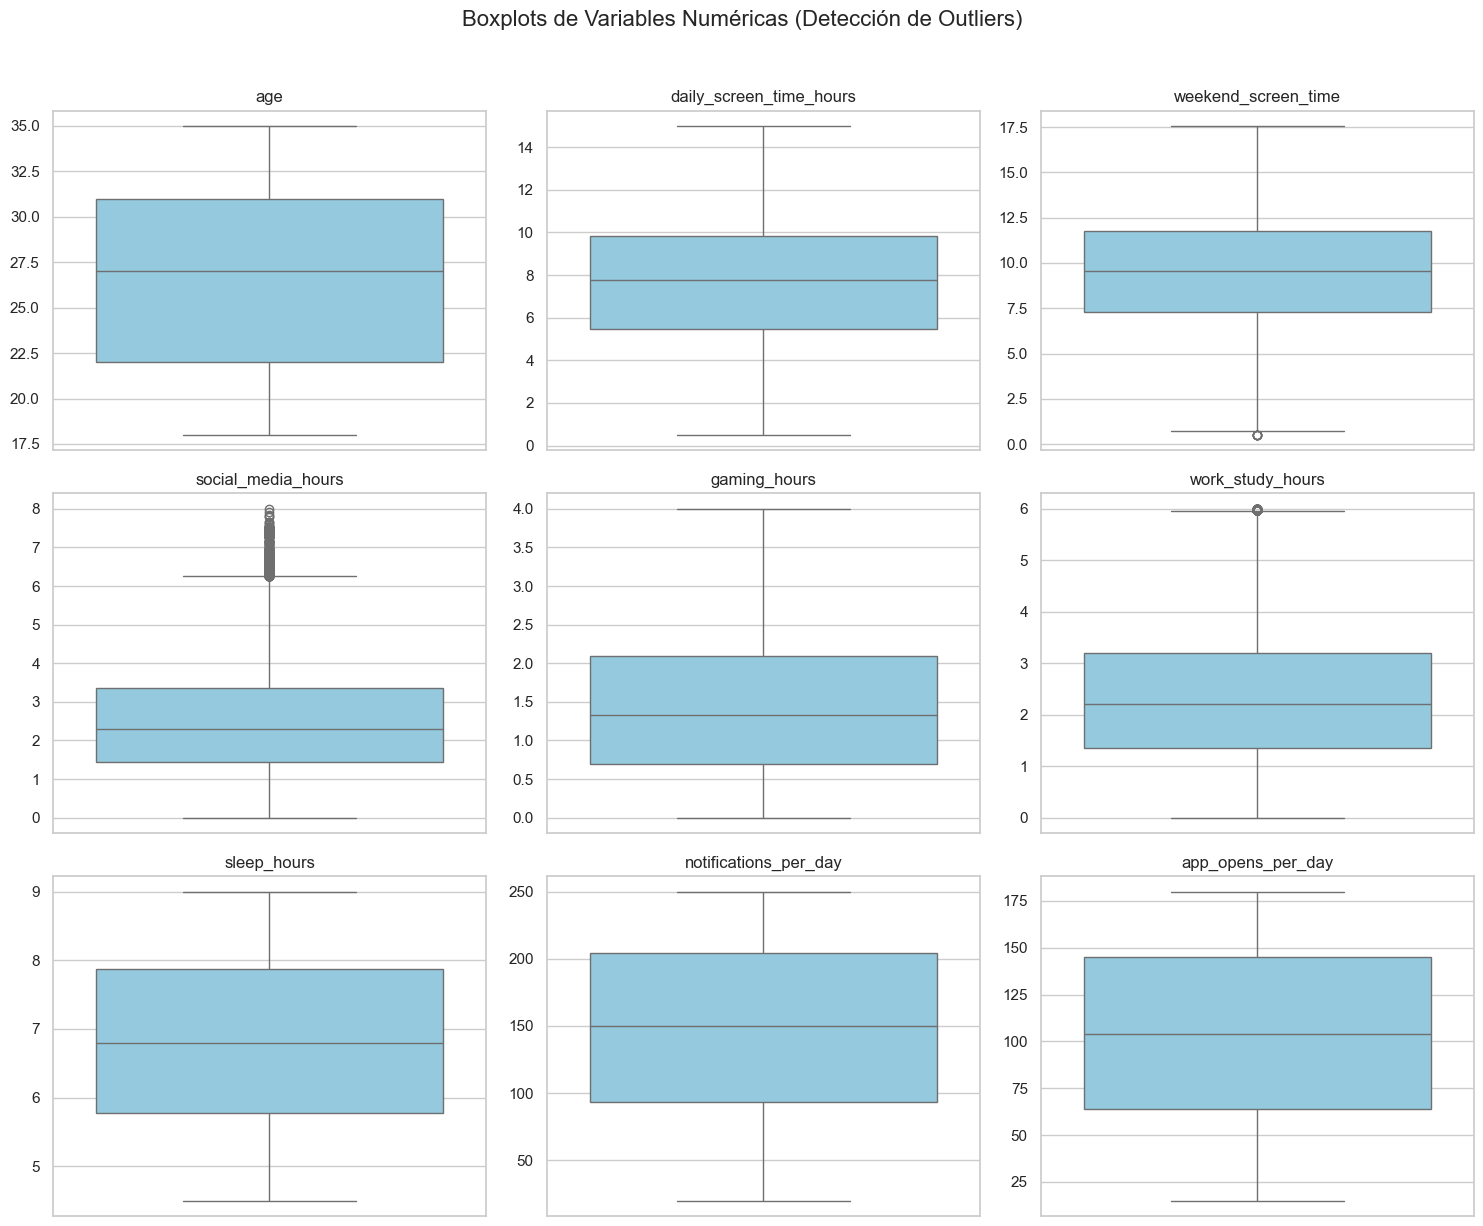

In [7]:
# Seleccionamos las columnas numéricas que queremos analizar
num_cols = [
    'age', 'daily_screen_time_hours', 'weekend_screen_time', 
    'social_media_hours', 'gaming_hours', 'work_study_hours', 
    'sleep_hours', 'notifications_per_day', 'app_opens_per_day'
]

# Creamos una figura con subgráficos para los Boxplots
plt.figure(figsize=(15, 12))
plt.suptitle('Boxplots de Variables Numéricas (Detección de Outliers)', fontsize=16, y=1.02)

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1) # Matriz de 3x3 gráficos
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
    plt.ylabel('') # Ocultamos el nombre del eje Y para que quede más limpio

plt.tight_layout()
plt.show()

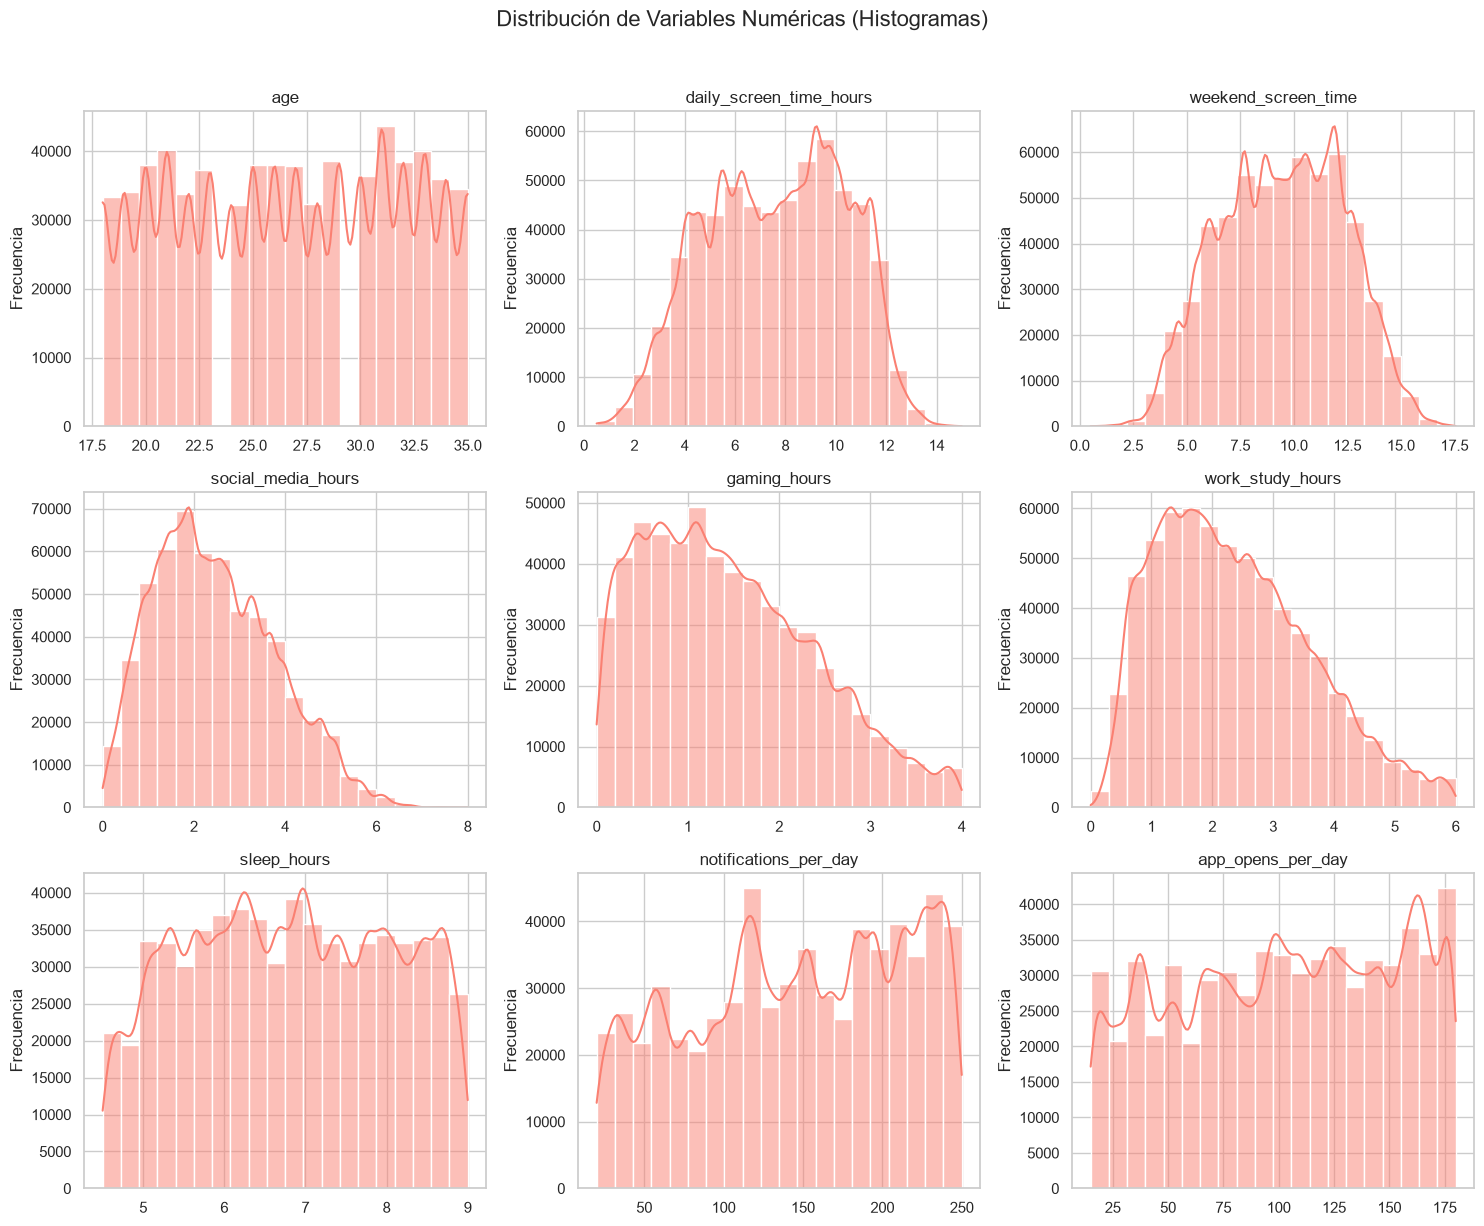

In [8]:
# Creamos una figura con subgráficos para los Histogramas
plt.figure(figsize=(15, 12))
plt.suptitle('Distribución de Variables Numéricas (Histogramas)', fontsize=16, y=1.02)

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], bins=20, kde=True, color='salmon')
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**¿Qué problemas encontramos y qué decisiones tomamos?**

1. **Valores Faltantes:** Confirmamos que nuestra variable objetivo `addicted_label` está completa (0 nulos), lo cual es ideal. Sin embargo, las variables predictoras presentan entre un 4% y un 19% de datos faltantes. 
   * *Decisión:* No eliminaremos las filas con nulos (DropNA) para no perder volumen de datos. En la etapa de modelado aplicaremos un pipeline de imputación (mediana para numéricas y moda para categóricas).
2. **Distribución y Valores Atípicos (Outliers):** Tanto la estadística descriptiva como los Boxplots demuestran que **no existen valores atípicos severos** ni errores lógicos. 
   * La edad está acotada entre 18 y 35 años exactos.
   * Los tiempos máximos de uso diario (15 hrs) y horas de sueño (4.5 a 9 hrs) están dentro de límites reales, y solo unos pocos puntos superan los bigotes (≈ 1.200 en redes sociales y ≈ 300 en trabajo/estudio, a lo más el 0,22 % de los datos observados), todos con valores plausibles (ver sección 3.3).
   * *Decisión:* Al no existir valores extremos irreales, no será necesario aplicar técnicas de recorte ni eliminar outliers antes de modelar.
3. **Categorías y Duplicados:** Las variables categóricas (`gender`, `stress_level`, `academic_work_impact`) están completamente limpias, sin categorías solapadas. Además, el dataset tiene 0 registros duplicados.
4. **Cobertura Temporal/Contextual ($T$):** El dataset no tiene fechas; el único contraste temporal disponible es día hábil contra fin de semana.

---
## 3. Revisión complementaria de calidad

La revisión anterior respondió *cuántos* problemas hay. Antes de pasar al análisis descriptivo, profundizamos en cuatro preguntas que afectan directamente las decisiones de preparación:

1. ¿Los valores faltantes siguen algún patrón o están relacionados con $Y$?
2. ¿Las variables son coherentes **entre sí** (no solo dentro de su propio rango)?
3. ¿Hay valores atípicos o valores que se repiten de forma sospechosa?
4. ¿Qué cobertura contextual tienen los datos?

Al final de esta sección se resumen las decisiones de preparación y se guarda el dataset preparado en `data/processed/`.

In [8]:
# Librerías adicionales para el análisis de relaciones
from scipy import stats
from sklearn.metrics import roc_auc_score, mutual_info_score
from sklearn.model_selection import StratifiedKFold

Y = 'addicted_label'
cat_cols = ['gender', 'stress_level', 'academic_work_impact']
predictores = num_cols + cat_cols

# Nombres legibles y unidades para títulos y ejes de los gráficos
NOMBRES = {
    'age': ('Edad', 'años'),
    'daily_screen_time_hours': ('Pantalla diaria', 'h/día'),
    'weekend_screen_time': ('Pantalla fin de semana', 'h/día'),
    'social_media_hours': ('Redes sociales', 'h/día'),
    'gaming_hours': ('Videojuegos', 'h/día'),
    'work_study_hours': ('Trabajo/estudio', 'h/día'),
    'sleep_hours': ('Sueño', 'h/noche'),
    'notifications_per_day': ('Notificaciones', 'por día'),
    'app_opens_per_day': ('Aperturas de apps', 'por día'),
    'gender': ('Género', ''),
    'stress_level': ('Nivel de estrés', ''),
    'academic_work_impact': ('Impacto académico/laboral', ''),
}
ORDEN_CAT = {
    'gender': ['Male', 'Female', 'Other'],
    'stress_level': ['Low', 'Medium', 'High'],
    'academic_work_impact': ['No', 'Yes'],
}
# Traducción de las categorías solo para mostrar en los gráficos
TRADUCCION = {'Male': 'Hombre', 'Female': 'Mujer', 'Other': 'Otro', 'Low': 'Bajo', 'Medium': 'Medio',
              'High': 'Alto', 'No': 'No', 'Yes': 'Sí'}

# Mismos colores que la app Streamlit: azul = Y=0, naranjo = Y=1
COLOR_Y = {0: '#2a78d6', 1: '#eb6834'}
GRIS = '#898781'
TASA_GLOBAL = df[Y].mean()


def nombre(col):
    return NOMBRES[col][0]


def etiqueta(col):
    # Nombre legible con su unidad, para los ejes
    nom, unidad = NOMBRES[col]
    return f'{nom} ({unidad})' if unidad else nom


def cramer_v(x, y):
    # V de Cramér: 0 = sin asociación, 1 = asociación total
    tabla = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tabla)[0]
    return np.sqrt(chi2 / (tabla.values.sum() * (min(tabla.shape) - 1)))


def linea_tasa_global(ax):
    ax.axhline(TASA_GLOBAL * 100, color=GRIS, ls=':', lw=1)
    ax.text(ax.get_xlim()[0], TASA_GLOBAL * 100 + 1.5, f' Promedio global {TASA_GLOBAL:.1%}',
            color=GRIS, fontsize=8, va='bottom')

### 3.1 Patrón de los valores faltantes

No basta con saber cuántos datos faltan: si los faltantes se concentraran en un tipo de persona (por ejemplo, en quienes tienen uso problemático), imputarlos con la mediana introduciría un sesgo.

In [9]:
nulos_por_fila = df[predictores].isna().sum(axis=1)
print(f"Filas completas (sin ningún faltante): {(nulos_por_fila == 0).mean():.1%}")
print(f"Filas con 3 o más predictores faltantes: {(nulos_por_fila >= 3).mean():.1%}")
print(f"Máximo de faltantes en una misma fila: {nulos_por_fila.max()} de {len(predictores)} predictores\n")

# ¿El hecho de que falte un dato se relaciona con Y?
filas = []
for col in predictores:
    falta = df[col].isna()
    filas.append({
        'Variable': nombre(col),
        '% faltante': falta.mean() * 100,
        '% Y=1 cuando falta': df.loc[falta, Y].mean() * 100,
        '% Y=1 cuando está': df.loc[~falta, Y].mean() * 100,
    })
nulos_vs_y = pd.DataFrame(filas).set_index('Variable').sort_values('% faltante', ascending=False)
nulos_vs_y['Diferencia (p.p.)'] = nulos_vs_y['% Y=1 cuando falta'] - nulos_vs_y['% Y=1 cuando está']
display(nulos_vs_y.round(2))

Filas completas (sin ningún faltante): 38.9%
Filas con 3 o más predictores faltantes: 17.5%
Máximo de faltantes en una misma fila: 11 de 12 predictores



,% faltante,% Y=1 cuando falta,% Y=1 cuando está,Diferencia (p.p.)
Variable,,,,
Redes sociales,19.38,70.94,70.94,-0.00
Videojuegos,18.34,71.05,70.92,0.13
Pantalla fin de semana,16.21,71.07,70.92,0.15
Pantalla diaria,13.86,71.13,70.91,0.22
Aperturas de apps,11.67,71.28,70.90,0.38
Notificaciones,9.78,71.02,70.93,0.09
Nivel de estrés,7.98,70.90,70.95,-0.05
Trabajo/estudio,7.45,71.06,70.93,0.13
Sueño,6.43,71.34,70.92,0.42


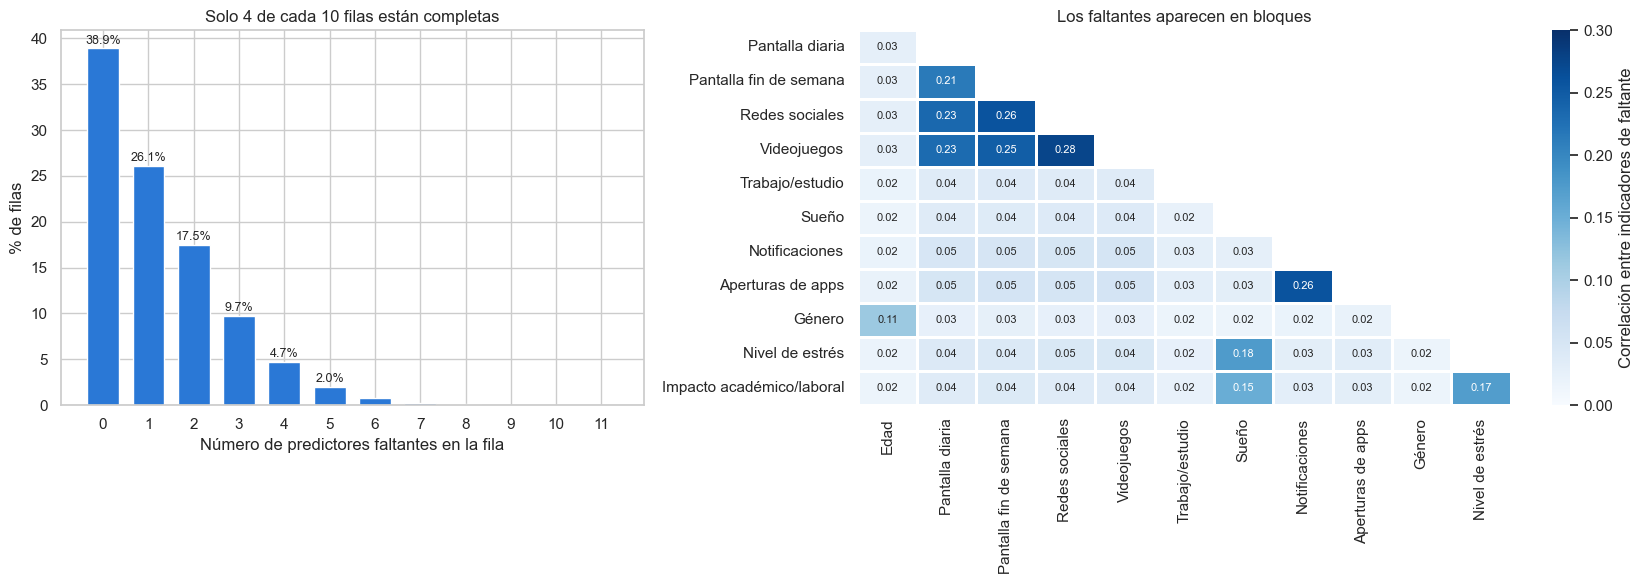

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'width_ratios': [1, 1.4]})

# (a) Cuántos faltantes tiene cada fila
conteo = nulos_por_fila.value_counts(normalize=True).sort_index() * 100
axes[0].bar(conteo.index, conteo.values, color=COLOR_Y[0], width=0.7)
for x, v in conteo.items():
    if v >= 1:
        axes[0].text(x, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
axes[0].set_xticks(conteo.index)
axes[0].set_xlabel('Número de predictores faltantes en la fila')
axes[0].set_ylabel('% de filas')
axes[0].set_title('Solo 4 de cada 10 filas están completas')

# (b) ¿Los faltantes aparecen juntos? Correlación entre indicadores de faltante
corr_nulos = df[predictores].isna().corr()
corr_nulos.index = corr_nulos.columns = [nombre(c) for c in predictores]
corr_nulos = corr_nulos.iloc[1:, :-1]  # se omiten la fila y columna que quedarían vacías
mascara = np.triu(np.ones_like(corr_nulos, dtype=bool), k=1)
sns.heatmap(corr_nulos, mask=mascara, cmap='Blues', vmin=0, vmax=0.3, annot=True, fmt='.2f',
            annot_kws={'size': 8}, linewidths=1, linecolor='white', ax=axes[1],
            cbar_kws={'label': 'Correlación entre indicadores de faltante'})
axes[1].grid(False)
axes[1].set_title('Los faltantes aparecen en bloques')
plt.tight_layout()
plt.show()

**Interpretación:**

* **Los faltantes están muy repartidos:** aunque ninguna variable supera el 19 % de faltantes, solo el **38,9 %** de las filas está completa. Eliminar filas con nulos (`dropna`) descartaría más del 60 % de la muestra, lo que confirma la decisión de **no** eliminarlas.
* **Los faltantes no son informativos respecto de $Y$:** en todas las variables, la tasa de uso problemático es prácticamente igual cuando el dato falta y cuando está (diferencias menores a 0,5 puntos porcentuales). No hay evidencia de que falte información de forma sistemática en un grupo, por lo que una imputación simple no debería sesgar la relación con $Y$ y no es necesario agregar indicadores de faltante.
* **Pero no son completamente aleatorios entre sí:** los faltantes aparecen en cuatro bloques que parecen secciones de un cuestionario: **uso de pantalla** (pantalla diaria, fin de semana, redes sociales y videojuegos; correlaciones de 0,21 a 0,28), **notificaciones–aperturas** (0,26), **bienestar** (sueño, estrés e impacto académico; 0,15 a 0,18) y **demografía** (edad–género; 0,11). Cuando falta una variable, a menudo también falta otra del mismo bloque, justo la que más podría ayudar a imputarla. En el Avance 3 conviene comparar la imputación por mediana/moda con una imputación multivariada (KNN o iterativa) que use variables de otros bloques.

### 3.2 Coherencia interna entre variables

Además de revisar rangos individuales, verificamos restricciones lógicas entre variables: el tiempo de pantalla diario debería ser **mayor o igual** que la suma de sus componentes (redes sociales + videojuegos + trabajo/estudio), y el tiempo de pantalla más las horas de sueño no puede superar 24 h.

In [11]:
componentes = ['social_media_hours', 'gaming_hours', 'work_study_hours']
comp = df[['daily_screen_time_hours'] + componentes].dropna()
suma_componentes = comp[componentes].sum(axis=1)
otros_usos = comp['daily_screen_time_hours'] - suma_componentes

print(f"Filas con pantalla diaria y sus 3 componentes observados: {len(comp):,}")
print(f"  % donde pantalla diaria >= redes + videojuegos + trabajo/estudio: {(otros_usos >= -0.01).mean():.2%}")
print(f"  Correlación entre pantalla diaria y la suma de componentes: {suma_componentes.corr(comp['daily_screen_time_hours']):.3f}")
print(f"  Tiempo restante ('otros usos'): mediana {otros_usos.median():.2f} h, máximo {otros_usos.max():.2f} h\n")

pantalla_sueno = df[['daily_screen_time_hours', 'sleep_hours']].dropna()
print(f"Casos con pantalla diaria + sueño > 24 h: {(pantalla_sueno.sum(axis=1) > 24).sum()}")

semana_finde = df[['daily_screen_time_hours', 'weekend_screen_time']].dropna()
print(f"% de personas con más pantalla el fin de semana que en un día hábil: "
      f"{(semana_finde['weekend_screen_time'] > semana_finde['daily_screen_time_hours']).mean():.1%}")

Filas con pantalla diaria y sus 3 componentes observados: 421,427
  % donde pantalla diaria >= redes + videojuegos + trabajo/estudio: 100.00%
  Correlación entre pantalla diaria y la suma de componentes: 0.838
  Tiempo restante ('otros usos'): mediana 0.75 h, máximo 11.53 h

Casos con pantalla diaria + sueño > 24 h: 0
% de personas con más pantalla el fin de semana que en un día hábil: 85.1%


**Interpretación:**

* En el **100 %** de los casos el tiempo de pantalla diario es mayor o igual que la suma de sus componentes. Es decir, `daily_screen_time_hours` representa el **tiempo total**, y redes sociales, videojuegos y trabajo/estudio son partes de ese total; la diferencia corresponde a *otros usos* (mediana ≈ 0,75 h). Esta restricción se aprovecha para crear la variable derivada `otros_usos_hours` y puede ayudar a imputar (si falta el total, sabemos que es al menos la suma de sus partes).
* No existen combinaciones imposibles (pantalla + sueño > 24 h).
* Un 85 % usa más pantalla el fin de semana; el 15 % restante usa menos, lo que es plausible (por ejemplo, quienes usan pantallas principalmente para trabajar o estudiar).

### 3.3 Valores atípicos, extremos y valores repetidos

Los boxplots mostraron pocos puntos fuera de los bigotes. Aquí los cuantificamos con la regla del rango intercuartílico (valores bajo $Q_1 - 1{,}5\cdot IQR$ o sobre $Q_3 + 1{,}5\cdot IQR$) y revisamos si hay acumulaciones en los extremos del rango (posible truncamiento) o valores que se repiten más de lo esperable.

In [12]:
filas = []
for col in num_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    fuera = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    filas.append({
        'Variable': nombre(col),
        'Mín': s.min(),
        'Máx': s.max(),
        'Outliers IQR': int(fuera.sum()),
        '% outliers': fuera.mean() * 100,
        '% en el mínimo': (s == s.min()).mean() * 100,
        '% en el máximo': (s == s.max()).mean() * 100,
        'Valores únicos': s.nunique(),
    })
display(pd.DataFrame(filas).set_index('Variable').round(3))

,Mín,Máx,Outliers IQR,% outliers,% en el mínimo,% en el máximo,Valores únicos
Variable,,,,,,,
Edad,18.00,35.00,0,0.000,5.024,5.210,18
Pantalla diaria,0.50,15.00,0,0.000,0.043,0.001,1389
Pantalla fin de semana,0.51,17.56,6,0.001,0.001,0.002,1437
Redes sociales,0.00,8.00,1209,0.217,0.002,0.000,721
Videojuegos,0.00,4.00,0,0.000,0.019,0.002,401
Trabajo/estudio,0.00,6.00,300,0.047,0.001,0.001,600
Sueño,4.50,9.00,0,0.000,0.026,0.003,451
Notificaciones,20.00,250.00,0,0.000,0.371,0.257,231
Aperturas de apps,15.00,180.00,0,0.000,0.396,0.701,166


Notificaciones: 231 valores distintos; frecuencia por valor entre 289 y 9,591 (promedio 2,700; desviación estándar 1,735)
Aperturas de apps: 166 valores distintos; frecuencia por valor entre 710 y 10,734 (promedio 3,679; desviación estándar 1,846)


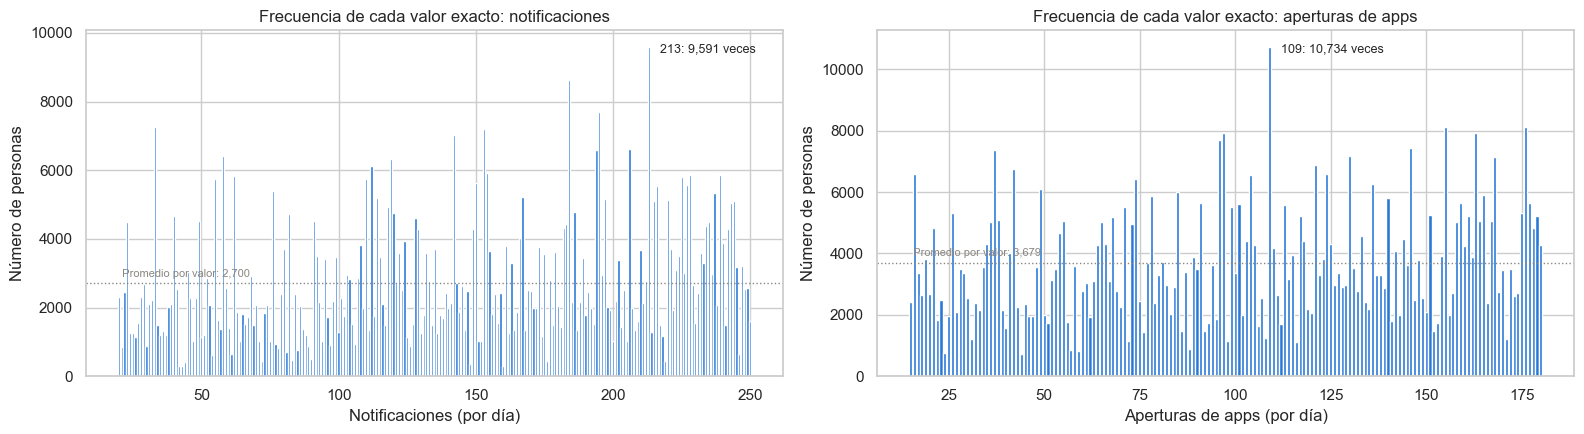

In [13]:
# En las variables de conteo (números enteros), ¿todos los valores aparecen con frecuencia similar?
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, col in zip(axes, ['notifications_per_day', 'app_opens_per_day']):
    frec = df[col].value_counts().sort_index()
    promedio = frec.mean()
    ax.bar(frec.index, frec.values, width=0.8, color=COLOR_Y[0])
    ax.axhline(promedio, color=GRIS, ls=':', lw=1)
    ax.text(frec.index.min(), promedio * 1.05, f' Promedio por valor: {promedio:,.0f}', color=GRIS, fontsize=8, va='bottom')
    top = frec.idxmax()
    ax.annotate(f'{top:.0f}: {frec.max():,} veces', xy=(top, frec.max()), xytext=(8, -4),
                textcoords='offset points', fontsize=9)
    ax.set_title(f'Frecuencia de cada valor exacto: {nombre(col).lower()}')
    ax.set_xlabel(etiqueta(col))
    ax.set_ylabel('Número de personas')
    print(f"{nombre(col)}: {frec.size} valores distintos; frecuencia por valor entre {frec.min():,} y {frec.max():,} "
          f"(promedio {promedio:,.0f}; desviación estándar {frec.std():,.0f})")
plt.tight_layout()
plt.show()

**Interpretación:**

* **Outliers estadísticos escasos y plausibles:** la regla IQR marca solo 1.209 casos en redes sociales (0,22 % de los valores observados, entre 6,25 y 8 h diarias), 300 en trabajo/estudio (0,05 %) y 6 en fin de semana. Son valores posibles en la vida real, no errores de registro, por lo que **se mantienen** sin recorte. (Esto precisa la conclusión anterior: sí hay algunos puntos fuera de los bigotes, pero ninguno es irreal.)
* **Sin acumulaciones en los extremos:** salvo la edad (discreta, donde cada año concentra ≈ 5 %), menos del 1 % de los datos cae exactamente en el mínimo o en el máximo de cada variable, por lo que no hay evidencia de truncamiento. Los rangos (redes ≤ 8 h, videojuegos ≤ 4 h, trabajo/estudio ≤ 6 h, sueño entre 4,5 y 9 h) parecen límites definidos al generar o recolectar los datos.
* **Valores exactos repetidos de forma irregular:** en notificaciones y aperturas de apps, algunos valores se repiten mucho más que otros (por ejemplo, 213 notificaciones aparece 9.591 veces, ≈ 3,6 veces el promedio por valor) y la frecuencia por valor varía entre ≈ 300 y ≈ 10.700. En un conteo real se esperaría una variación suave entre valores vecinos. Este patrón de "picos" es típico de **datos sintéticos** generados a partir de un dataset original más pequeño (como los de Kaggle *Playground*). Lo retomamos en la sección 6.4, porque estos valores especiales resultan estar asociados con $Y$.

### 3.4 Cobertura temporal y contextual

* **Temporal:** el dataset no tiene fechas. Cada fila describe los hábitos de una persona en una semana típica (diseño transversal). La única dimensión temporal disponible es el contraste **día hábil vs fin de semana** (`daily_screen_time_hours` vs `weekend_screen_time`), que se analiza en la sección 7.
* **Contextual:** revisamos que los grupos de contexto estén representados de forma suficiente (porcentajes calculados sobre los valores observados).

In [14]:
grupo_edad = pd.cut(df['age'], bins=[17, 22, 27, 31, 35], labels=['18–22', '23–27', '28–31', '32–35'])

cobertura = {nombre(col): df[col].value_counts(normalize=True) * 100 for col in cat_cols}
cobertura['Grupo de edad'] = grupo_edad.value_counts(normalize=True, sort=False) * 100
for variable, dist in cobertura.items():
    print(f"{variable}: " + ' | '.join(f'{k}: {v:.1f}%' for k, v in dist.items()))
print(f"\nEdad: de {df['age'].min():.0f} a {df['age'].max():.0f} años ({df['age'].nunique()} valores enteros distintos)")

Género: Male: 33.8% | Female: 33.5% | Other: 32.8%
Nivel de estrés: High: 34.7% | Low: 32.7% | Medium: 32.6%
Impacto académico/laboral: Yes: 51.1% | No: 48.9%
Grupo de edad: 18–22: 27.1% | 23–27: 27.7% | 28–31: 22.8% | 32–35: 22.5%

Edad: de 18 a 35 años (18 valores enteros distintos)


Todos los grupos de contexto están **balanceados**: ≈ 1/3 por género y por nivel de estrés, ≈ 50/50 en impacto académico/laboral y entre 22 % y 28 % en cada grupo de edad. No hay categorías raras ni grupos subrepresentados, así que cualquier diferencia de $Y$ entre grupos no se deberá a muestras pequeñas.

### 3.5 Resumen: problemas encontrados y decisiones de preparación

| Problema detectado | Evidencia | Decisión |
|---|---|---|
| `id` no aporta información | Identificador único por fila | Se excluye del análisis y del modelado |
| Faltantes en todos los predictores (4–19 %) | Solo 38,9 % de filas completas | **No** eliminar filas; imputar dentro del *pipeline* del Avance 3 (mediana/moda como base) |
| Faltantes no relacionados con $Y$ | Diferencia < 0,5 p.p. en la tasa de $Y$ | No se crean indicadores de faltante |
| Faltantes en bloques (tipo secciones de cuestionario) | Correlación entre faltantes de hasta 0,28 | Comparar imputación simple vs multivariada (KNN/iterativa) en el Avance 3 |
| Outliers estadísticos escasos | ≤ 0,22 % de los datos, valores plausibles | Se mantienen (sin recorte ni eliminación) |
| Pantalla diaria = tiempo total de uso | 100 % cumple pantalla ≥ suma de componentes | Variables derivadas `otros_usos_hours` y `prop_redes` (proporción del tiempo en redes) |
| Contraste semana / fin de semana ($T$) | 85 % usa más pantalla el fin de semana | Variable derivada `dif_finde_hours` |
| Categóricas sin inconsistencias | 2–3 niveles, sin variantes de escritura | Se tipifican como categorías; estrés como **ordinal** (Low < Medium < High) |
| Valores repetidos de forma irregular | Picos de frecuencia en notificaciones y aperturas | Se mantienen; se registran como **limitación** (posible origen sintético) |

Los faltantes se conservan deliberadamente en el dataset preparado: la imputación se hará dentro del *pipeline* de modelado para evitar fuga de información entre entrenamiento y prueba.

In [16]:
df_proc = df.drop(columns='id').copy()
for col, orden in ORDEN_CAT.items():
    df_proc[col] = pd.Categorical(df_proc[col], categories=orden, ordered=(col == 'stress_level'))

# Variables derivadas (quedan como NaN si falta alguna de las variables de origen)
df_proc['otros_usos_hours'] = (df_proc['daily_screen_time_hours'] - df_proc[componentes].sum(axis=1, min_count=3)).round(2)
df_proc['prop_redes'] = (df_proc['social_media_hours'] / df_proc['daily_screen_time_hours']).round(4)
df_proc['dif_finde_hours'] = (df_proc['weekend_screen_time'] - df_proc['daily_screen_time_hours']).round(2)

ruta_salida = '../data/processed/adiccion_pantalla_procesado.csv.gz'
df_proc.to_csv(ruta_salida, index=False)
print(f"Dataset preparado guardado en {ruta_salida}: {df_proc.shape[0]:,} filas x {df_proc.shape[1]} columnas")
display(df_proc.head())

Dataset preparado guardado en ../data/processed/adiccion_pantalla_procesado.csv.gz: 691,369 filas x 16 columnas


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,otros_usos_hours,prop_redes,dif_finde_hours
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1,NaN,NaN,NaN
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0,NaN,0.1809,NaN
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0,NaN,NaN,2.38
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1,0.38,0.1963,2.24
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1,4.57,0.1670,2.19


---
## 4. Análisis descriptivo y univariado

Resumimos cada variable numérica con medidas de tendencia central, dispersión, percentiles y forma. Dos medidas de forma ayudan a leer los histogramas de la sección 2.2:

* **Asimetría:** ≈ 0 indica una distribución simétrica; > 0 indica una cola hacia valores altos.
* **Curtosis (exceso):** ≈ 0 es similar a una normal; **≈ −1,2 es la firma de una distribución uniforme** (todos los valores igual de frecuentes).

In [17]:
datos_num = df[num_cols]
descriptivo = pd.DataFrame({
    'Unidad': [NOMBRES[c][1] for c in num_cols],
    'Media': datos_num.mean(),
    'Mediana': datos_num.median(),
    'Desv. est.': datos_num.std(),
    'CV (%)': datos_num.std() / datos_num.mean() * 100,
    'P5': datos_num.quantile(0.05),
    'P25': datos_num.quantile(0.25),
    'P75': datos_num.quantile(0.75),
    'P95': datos_num.quantile(0.95),
    'Asimetría': datos_num.skew(),
    'Curtosis': datos_num.kurt(),
})
descriptivo.index = [nombre(c) for c in num_cols]
display(descriptivo.round(2))

,Unidad,Media,Mediana,Desv. est.,CV (%),P5,P25,P75,P95,Asimetría,Curtosis
Edad,años,26.62,27.00,5.15,19.36,18.00,22.00,31.00,35.00,-0.04,-1.22
Pantalla diaria,h/día,7.64,7.77,2.72,35.62,3.19,5.48,9.84,11.71,-0.13,-0.92
Pantalla fin de semana,h/día,9.48,9.58,2.86,30.13,4.72,7.28,11.75,13.96,-0.06,-0.76
Redes sociales,h/día,2.47,2.31,1.32,53.26,0.58,1.45,3.37,4.86,0.47,-0.38
Videojuegos,h/día,1.46,1.33,0.93,64.04,0.18,0.70,2.09,3.21,0.54,-0.46
Trabajo/estudio,h/día,2.37,2.20,1.26,53.18,0.63,1.36,3.20,4.71,0.56,-0.32
Sueño,h/noche,6.80,6.80,1.23,18.14,4.84,5.78,7.87,8.73,-0.01,-1.13
Notificaciones,por día,145.89,150.00,65.92,45.18,33.00,93.00,204.00,240.00,-0.21,-1.13
Aperturas de apps,por día,102.64,104.00,48.09,46.86,23.00,64.00,145.00,175.00,-0.13,-1.17


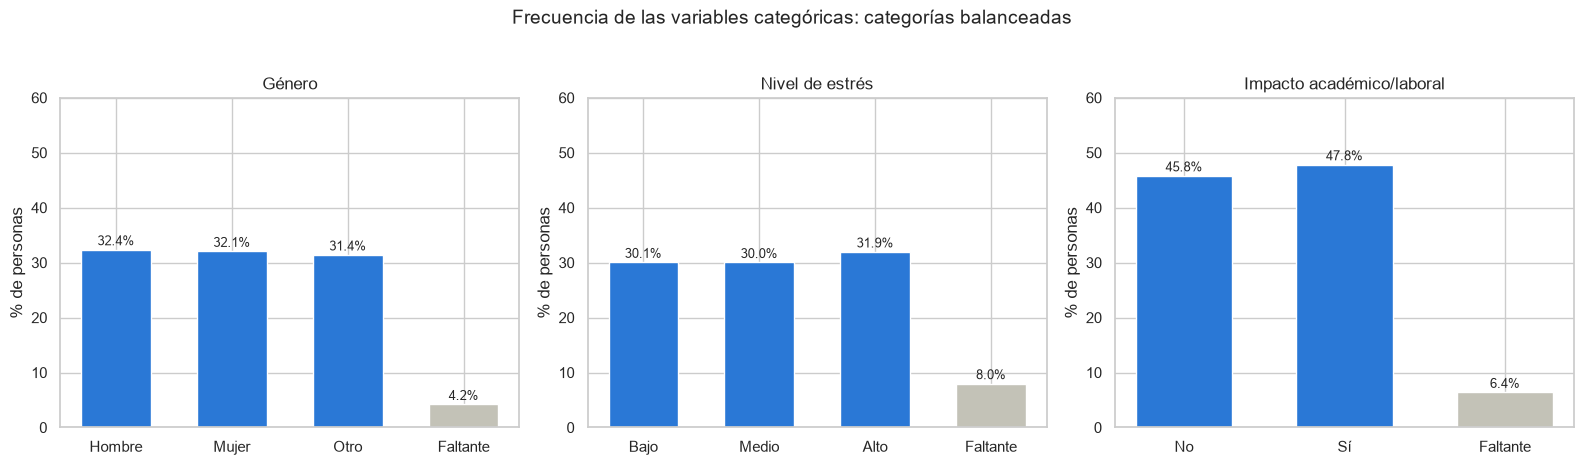

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, cat_cols):
    etiquetas = [TRADUCCION[c] for c in ORDEN_CAT[col]] + ['Faltante']
    porcentajes = [(df[col] == c).mean() * 100 for c in ORDEN_CAT[col]] + [df[col].isna().mean() * 100]
    colores = [COLOR_Y[0]] * len(ORDEN_CAT[col]) + ['#c3c2b7']
    ax.bar(etiquetas, porcentajes, color=colores, width=0.6)
    for i, v in enumerate(porcentajes):
        ax.text(i, v + 0.8, f'{v:.1f}%', ha='center', fontsize=9)
    ax.set_ylim(0, 60)
    ax.set_title(nombre(col))
    ax.set_ylabel('% de personas')
plt.suptitle('Frecuencia de las variables categóricas: categorías balanceadas', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

**Interpretación por grupos de variables:**

1. **Tiempo de pantalla (diario y fin de semana): distribución en campana centrada en valores altos.** La media diaria es 7,6 h y la mediana 7,8 h (casi simétrica, asimetría ≈ −0,1); la mitad de las personas usa entre 5,5 y 9,8 h al día. El fin de semana todo se desplaza ≈ 1,8 h hacia arriba (media 9,5 h). El uso intensivo es la norma en esta población, lo que es coherente con que la mayoría esté etiquetada con uso problemático (sección 5).
2. **Componentes del uso (redes sociales, videojuegos, trabajo/estudio): asimetría positiva (0,47–0,56).** La mayoría tiene un uso moderado (medianas de 2,3 h, 1,3 h y 2,2 h) y existe una cola de usuarios intensivos; por ejemplo, el 5 % con más uso de redes supera las 4,9 h diarias. Son las variables de horas con mayor dispersión relativa (CV 53–64 %).
3. **Edad, sueño, notificaciones y aperturas de apps: distribución prácticamente uniforme** (curtosis entre −1,13 y −1,22, muy cerca del −1,2 teórico; media ≈ mediana). En una población real el sueño se concentraría alrededor de 7 h y no se repartiría por igual entre 4,5 y 9 h; esto refuerza la sospecha de **datos sintéticos**.
4. **Categóricas:** las tres están balanceadas y tienen entre 4 % y 8 % de faltantes. No hay categorías raras que requieran agruparse.

> **Para el modelado:** las escalas son muy distintas (horas vs. conteos de 15 a 250), por lo que los modelos sensibles a la escala (regresión logística, KNN) requerirán estandarización. La asimetría es moderada, así que no parece necesario aplicar transformaciones logarítmicas.

---
## 5. Análisis de la variable objetivo $Y$ (`addicted_label`)

Comprender $Y$ es clave para elegir y evaluar modelos en el Avance 3: ¿cómo se distribuye?, ¿está balanceada?, ¿cambia entre grupos?

Y = 0 (sin uso problemático): 200,895 personas (29.1%)
Y = 1 (con uso problemático): 490,474 personas (70.9%)
Razón de clases (Y=1 : Y=0): 2.44 : 1
Accuracy de un modelo trivial que siempre predice Y=1: 70.9%


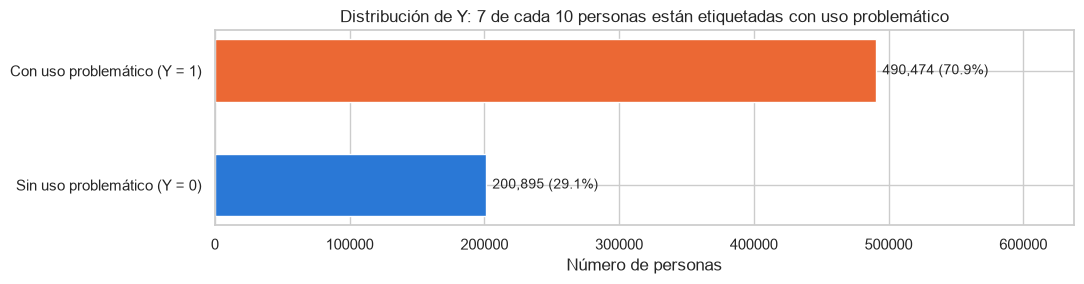

In [19]:
conteo_y = df[Y].value_counts().sort_index()
porc_y = df[Y].value_counts(normalize=True).sort_index() * 100
print(f"Y = 0 (sin uso problemático): {conteo_y[0]:,} personas ({porc_y[0]:.1f}%)")
print(f"Y = 1 (con uso problemático): {conteo_y[1]:,} personas ({porc_y[1]:.1f}%)")
print(f"Razón de clases (Y=1 : Y=0): {conteo_y[1] / conteo_y[0]:.2f} : 1")
print(f"Accuracy de un modelo trivial que siempre predice Y=1: {porc_y[1]:.1f}%")

fig, ax = plt.subplots(figsize=(11, 3))
etiquetas_y = ['Sin uso problemático (Y = 0)', 'Con uso problemático (Y = 1)']
ax.barh(etiquetas_y, conteo_y.values, color=[COLOR_Y[0], COLOR_Y[1]], height=0.55)
for i, (n, p) in enumerate(zip(conteo_y.values, porc_y.values)):
    ax.text(n + 5000, i, f'{n:,} ({p:.1f}%)', va='center', fontsize=10)
ax.set_xlim(0, conteo_y.max() * 1.3)
ax.set_xlabel('Número de personas')
ax.set_title('Distribución de Y: 7 de cada 10 personas están etiquetadas con uso problemático')
plt.tight_layout()
plt.show()

### 5.1 ¿Cambia $Y$ entre grupos de contexto?

Comparamos la tasa de uso problemático por género, nivel de estrés, impacto académico/laboral y grupo de edad. Con casi 700 mil observaciones, cualquier diferencia mínima resulta "estadísticamente significativa" (p-valor < 0,05); por eso, además del test chi-cuadrado, reportamos la **V de Cramér**, que mide el *tamaño* de la asociación (valores < 0,1 se consideran despreciables).

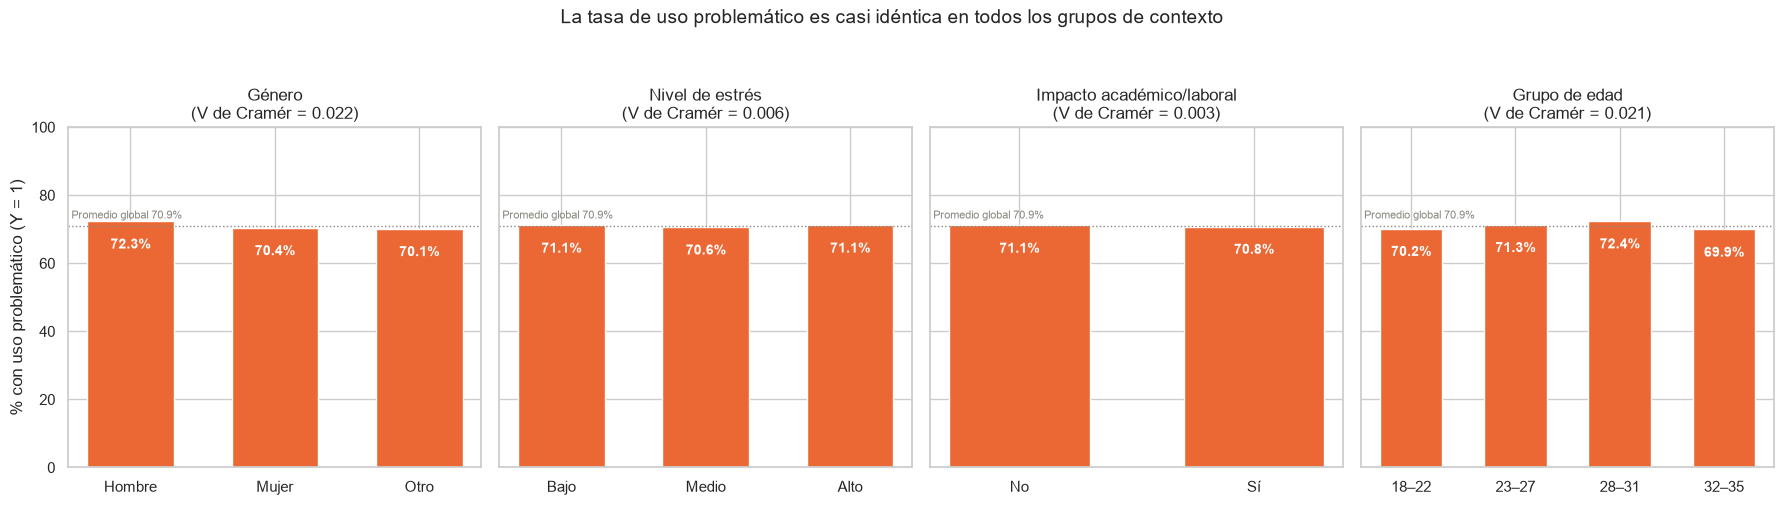

,Tasa mín. (%),Tasa máx. (%),Diferencia (p.p.),p-valor chi²,V de Cramér
Variable,,,,,
Género,70.102,72.320,2.218,7.3e-69,0.022
Nivel de estrés,70.566,71.143,0.577,2.0e-05,0.006
Impacto académico/laboral,70.788,71.103,0.315,5.4e-03,0.003
Grupo de edad,69.922,72.379,2.456,2.0e-62,0.021


In [20]:
df_ctx = df.assign(grupo_edad=grupo_edad)
grupos = {'gender': 'Género', 'stress_level': 'Nivel de estrés',
          'academic_work_impact': 'Impacto académico/laboral', 'grupo_edad': 'Grupo de edad'}
orden_grupos = {**ORDEN_CAT, 'grupo_edad': ['18–22', '23–27', '28–31', '32–35']}

resumen_grupos = []
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8), sharey=True)
for ax, (col, titulo) in zip(axes, grupos.items()):
    d = df_ctx[[col, Y]].dropna()
    tasas = d.groupby(col, observed=True)[Y].mean().reindex(orden_grupos[col])
    p_valor = stats.chi2_contingency(pd.crosstab(d[col], d[Y]))[1]
    v = cramer_v(d[col], d[Y])
    resumen_grupos.append({
        'Variable': titulo,
        'Tasa mín. (%)': tasas.min() * 100,
        'Tasa máx. (%)': tasas.max() * 100,
        'Diferencia (p.p.)': (tasas.max() - tasas.min()) * 100,
        'p-valor chi²': f'{p_valor:.1e}',
        'V de Cramér': v,
    })
    ax.bar([TRADUCCION.get(c, c) for c in tasas.index.astype(str)], tasas.values * 100, color=COLOR_Y[1], width=0.6)
    for i, t in enumerate(tasas.values):
        ax.text(i, t * 100 - 8, f'{t:.1%}', ha='center', color='white', fontsize=10, fontweight='bold')
    linea_tasa_global(ax)
    ax.set_ylim(0, 100)
    ax.set_title(f'{titulo}\n(V de Cramér = {v:.3f})')
    ax.set_xlabel('')
axes[0].set_ylabel('% con uso problemático (Y = 1)')
plt.suptitle('La tasa de uso problemático es casi idéntica en todos los grupos de contexto', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

display(pd.DataFrame(resumen_grupos).set_index('Variable').round(3))

**Interpretación:**

* **$Y$ está desbalanceada, con la clase "problemática" como mayoritaria:** 70,9 % vs 29,1 % (razón ≈ 2,4 : 1). El desbalance es moderado (no extremo), pero suficiente para que un modelo trivial que siempre prediga "uso problemático" obtenga 70,9 % de *accuracy*. Por eso esa métrica será engañosa en el Avance 3.
* **$Y$ casi no cambia entre grupos de contexto:** la diferencia máxima entre categorías es de ≈ 2 p.p. en género (Hombre 72,3 % vs Otro 70,1 %) y en grupos de edad, y menor a 1 p.p. en estrés e impacto académico. Aunque los tests chi-cuadrado dan p < 0,05 (por el enorme tamaño muestral), todas las V de Cramér son ≤ 0,03: asociaciones **despreciables**. El uso problemático no se concentra en ningún grupo demográfico ni de estrés.
* **¿Cambia $Y$ en el tiempo?** No es posible evaluarlo: no hay fechas ni seguimiento. El único contraste temporal disponible (día hábil vs fin de semana) se analiza en la sección 7.

> **Para el modelado:** partición estratificada por $Y$; métricas F1, ROC-AUC, PR-AUC y *recall* de la clase minoritaria (Y=0); evaluar `class_weight='balanced'` o ajuste del umbral de decisión.

---
## 6. Relaciones entre los predictores $X$ y el objetivo $Y$

Pasamos de describir variables por separado a estudiar cómo se relacionan con $Y$. El objetivo no es demostrar causalidad, sino responder: **¿qué variables parecen aportar información sobre el uso problemático y de qué forma (lineal o no lineal)?**

### 6.1 Distribución de cada predictor numérico según $Y$

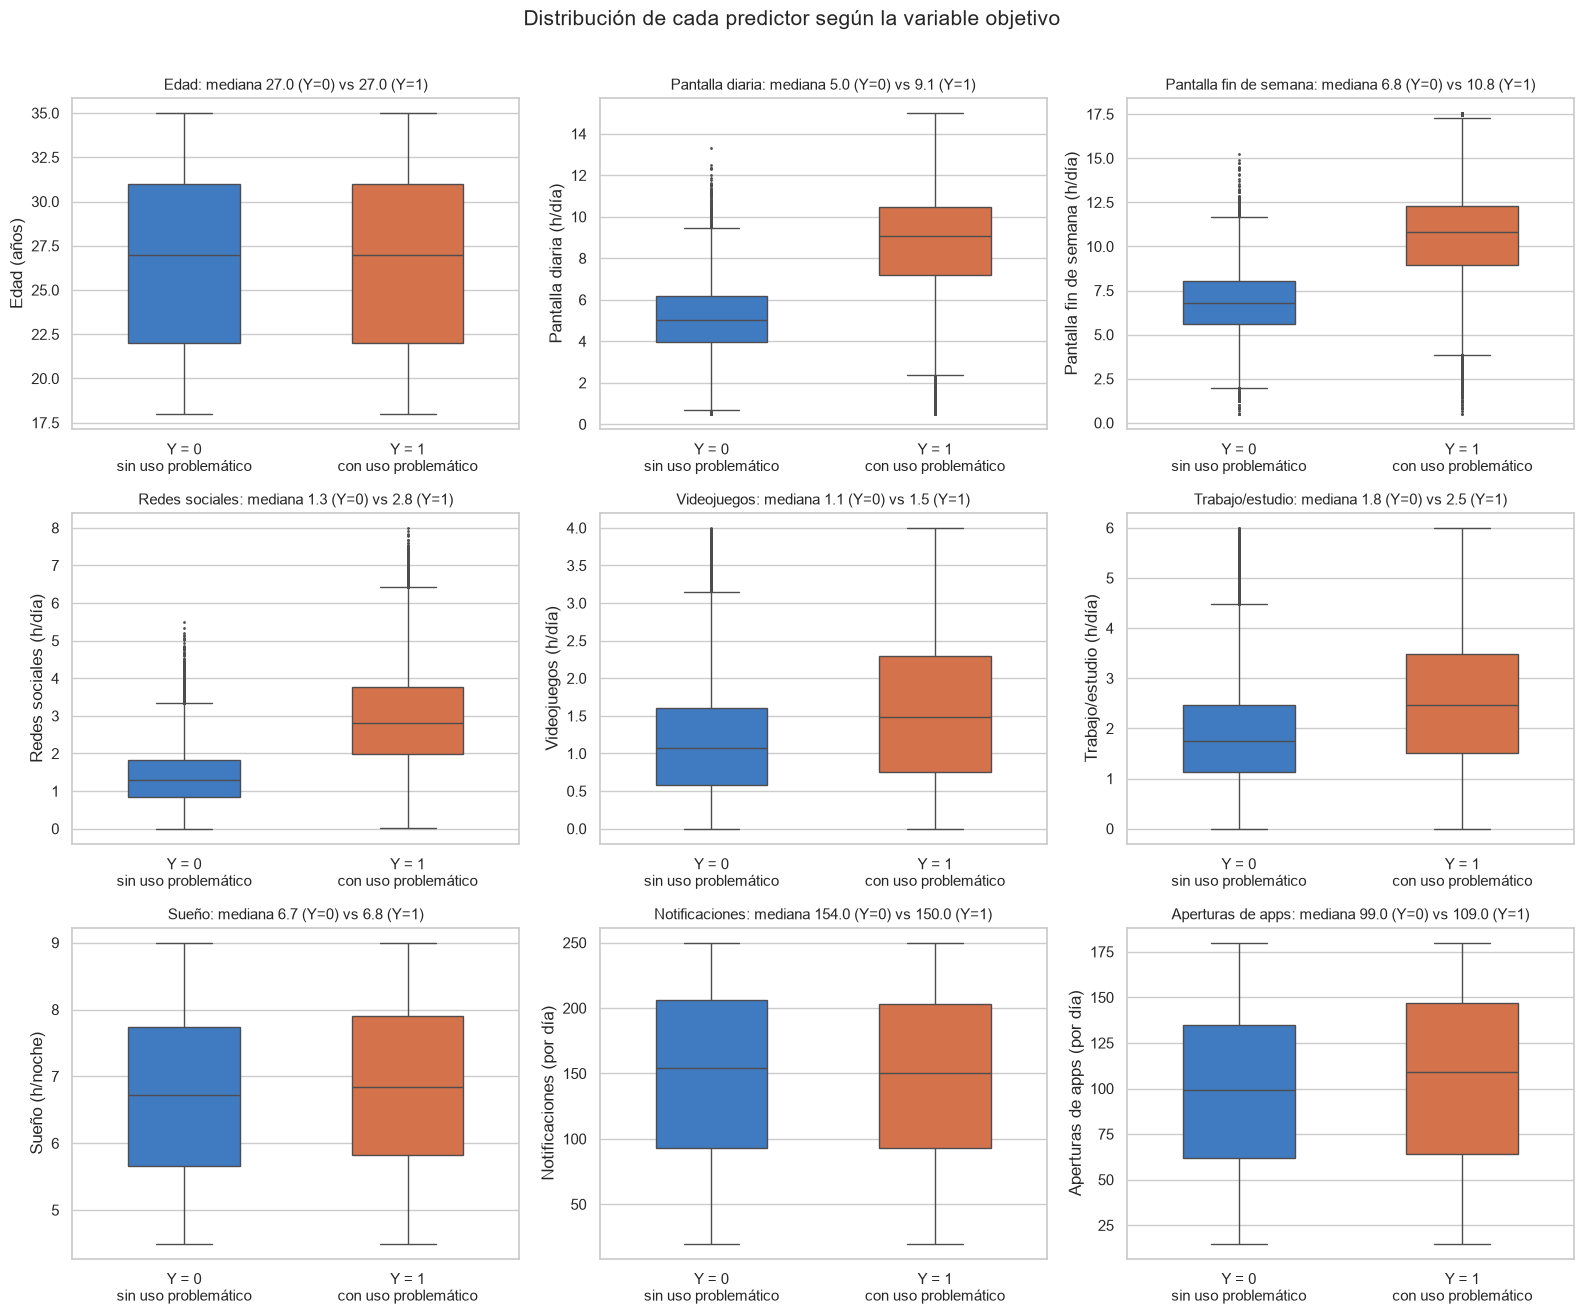

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x=Y, y=col, hue=Y, palette=COLOR_Y, legend=False, width=0.5, fliersize=1, ax=ax)
    medianas = df.groupby(Y)[col].median()
    ax.set_title(f'{nombre(col)}: mediana {medianas[0]:.1f} (Y=0) vs {medianas[1]:.1f} (Y=1)', fontsize=11)
    ax.set_xticks([0, 1], ['Y = 0\nsin uso problemático', 'Y = 1\ncon uso problemático'])
    ax.set_xlabel('')
    ax.set_ylabel(etiqueta(col))
plt.suptitle('Distribución de cada predictor según la variable objetivo', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Las cajas de **pantalla diaria, fin de semana y redes sociales** están claramente desplazadas hacia arriba en Y=1; en **videojuegos y trabajo/estudio** el desplazamiento es menor, y en **edad, sueño, notificaciones y aperturas** las cajas son prácticamente idénticas. A continuación cuantificamos estas diferencias.

### 6.2 Fuerza de la asociación: medidas lineales vs no lineales

Para cada predictor calculamos varias medidas complementarias. Comparar unas con otras permite detectar **relaciones no lineales**:

| Medida | Qué captura | Escala |
|---|---|---|
| Correlación punto-biserial | Relación **lineal** entre $X$ y $Y$ (equivale a Pearson con $Y$ binaria) | 0 = nada, ±1 = perfecta |
| AUC univariado | Relación **monótona**: probabilidad de que una persona con Y=1 tenga un valor de $X$ mayor (o menor) que una con Y=0 | 0,5 = azar, 1 = separación perfecta |
| Información mutua (por tramos) | Relación de **cualquier forma**, agrupando $X$ en 20 tramos de igual tamaño | 0 = independencia |
| AUC por valor exacto | Relación de cualquier forma usando cada **valor exacto** de $X$ como categoría (tasa de $Y$ por valor, estimada con validación cruzada de 5 folds para no sobreajustar) | 0,5 = azar |

Incluimos también las variables derivadas creadas en 3.5.

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def auc_valor_exacto(x, y, suavizado=20):
    # La tasa de Y de cada valor se calcula con 4/5 de los datos y se evalúa en el 1/5 restante
    prior = y.mean()
    puntaje = np.empty(len(x))
    for idx_ent, idx_val in skf.split(x, y):
        g = pd.DataFrame({'x': x[idx_ent], 'y': y[idx_ent]}).groupby('x')['y'].agg(['sum', 'count'])
        tasa = (g['sum'] + suavizado * prior) / (g['count'] + suavizado)
        puntaje[idx_val] = pd.Series(x[idx_val]).map(tasa).fillna(prior).to_numpy()
    return roc_auc_score(y, puntaje)


derivadas = {'otros_usos_hours': 'Otros usos (derivada)',
             'prop_redes': 'Proporción en redes (derivada)',
             'dif_finde_hours': 'Fin de semana − diario (derivada)'}
filas = []
for col in num_cols + list(derivadas):
    d = df_proc[[col, Y]].dropna()
    x, y = d[col].to_numpy(), d[Y].to_numpy()
    auc = roc_auc_score(y, x)
    tramos = pd.qcut(x, 20, labels=False, duplicates='drop')
    filas.append({
        'Variable': derivadas.get(col, nombre(col) if col in NOMBRES else col),
        'Mediana Y=0': np.median(x[y == 0]),
        'Mediana Y=1': np.median(x[y == 1]),
        'Corr. punto-biserial': stats.pointbiserialr(y, x)[0],
        'AUC (monótono)': max(auc, 1 - auc),
        'Inf. mutua (tramos)': mutual_info_score(tramos, y),
        # Para las derivadas (continuas, casi sin valores repetidos) el valor exacto no tiene sentido
        'AUC por valor exacto': auc_valor_exacto(x, y) if col in num_cols else np.nan,
    })
asociacion = pd.DataFrame(filas).set_index('Variable').sort_values('AUC (monótono)', ascending=False)
display(asociacion.round(3))

,Mediana Y=0,Mediana Y=1,Corr. punto-biserial,AUC (monótono),Inf. mutua (tramos),AUC por valor exacto
Variable,,,,,,
Pantalla diaria,5.040,9.070,0.611,0.890,0.242,0.899
Pantalla fin de semana,6.820,10.790,0.590,0.881,0.224,0.892
Redes sociales,1.290,2.820,0.532,0.858,0.187,0.863
Otros usos (derivada),0.480,0.950,0.305,0.765,0.099,NaN
Proporción en redes (derivada),0.271,0.356,0.241,0.660,0.035,NaN
Trabajo/estudio,1.750,2.470,0.251,0.655,0.038,0.675
Videojuegos,1.070,1.480,0.205,0.622,0.028,0.650
Aperturas de apps,99.000,109.000,0.063,0.541,0.008,0.752
Sueño,6.720,6.840,0.043,0.527,0.003,0.595


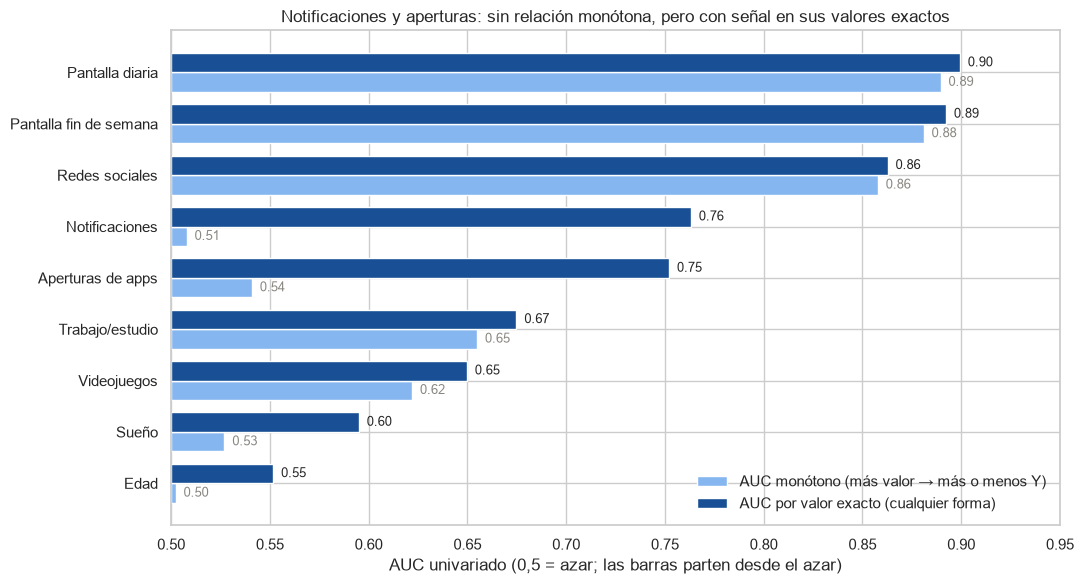

In [23]:
comparacion = (asociacion.loc[[nombre(c) for c in num_cols], ['AUC (monótono)', 'AUC por valor exacto']]
               .sort_values('AUC por valor exacto'))
fig, ax = plt.subplots(figsize=(11, 6))
posiciones = np.arange(len(comparacion))
alto = 0.38
ax.barh(posiciones - alto / 2, comparacion['AUC (monótono)'] - 0.5, left=0.5, height=alto,
        color='#86b6ef', label='AUC monótono (más valor → más o menos Y)')
ax.barh(posiciones + alto / 2, comparacion['AUC por valor exacto'] - 0.5, left=0.5, height=alto,
        color='#184f95', label='AUC por valor exacto (cualquier forma)')
for i, (a_mono, a_exacto) in enumerate(comparacion.values):
    ax.text(a_mono + 0.004, i - alto / 2, f'{a_mono:.2f}', va='center', fontsize=9, color=GRIS)
    ax.text(a_exacto + 0.004, i + alto / 2, f'{a_exacto:.2f}', va='center', fontsize=9)
ax.set_yticks(posiciones, comparacion.index)
ax.set_xlim(0.5, 0.95)
ax.set_xlabel('AUC univariado (0,5 = azar; las barras parten desde el azar)')
ax.set_title('Notificaciones y aperturas: sin relación monótona, pero con señal en sus valores exactos')
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

**Interpretación:**

* **Tres variables concentran la mayor parte de la información:** pantalla diaria (AUC 0,89), pantalla en fin de semana (0,88) y redes sociales (0,86). La mediana de pantalla diaria es 9,1 h en Y=1 frente a 5,0 h en Y=0 (≈ 4 h de diferencia), y la de redes sociales 2,8 h frente a 1,3 h.
* **Trabajo/estudio (0,65) y videojuegos (0,62) aportan de forma moderada.** La variable derivada *otros usos* (0,77) resulta más informativa que ambas: el tiempo total que no se explica por los tres componentes medidos también se asocia al uso problemático. *Proporción en redes* (0,66) aporta algo, pero menos que las horas absolutas.
* **Edad, sueño, notificaciones y aperturas de apps no tienen relación lineal ni monótona con $Y$** (AUC entre 0,50 y 0,54; correlación ≈ 0). Sin embargo, la última columna muestra algo inesperado: usando el **valor exacto**, notificaciones (≈ 0,76) y aperturas (≈ 0,75) sí separan $Y$. Existe una relación **no lineal** que la correlación no detecta; la estudiamos en 6.4.
* La **diferencia fin de semana − diario** tiene AUC ≈ 0,51: prácticamente no aporta (ver sección 7).

### 6.3 Forma de la relación: tasa de uso problemático por tramos

Para ver si la relación es lineal, agrupamos cada predictor en tramos y calculamos el % de personas con Y=1 en cada tramo. Una relación lineal se vería como una recta; una curva en S indica un **efecto umbral**. Se omiten los tramos con menos de 200 personas.

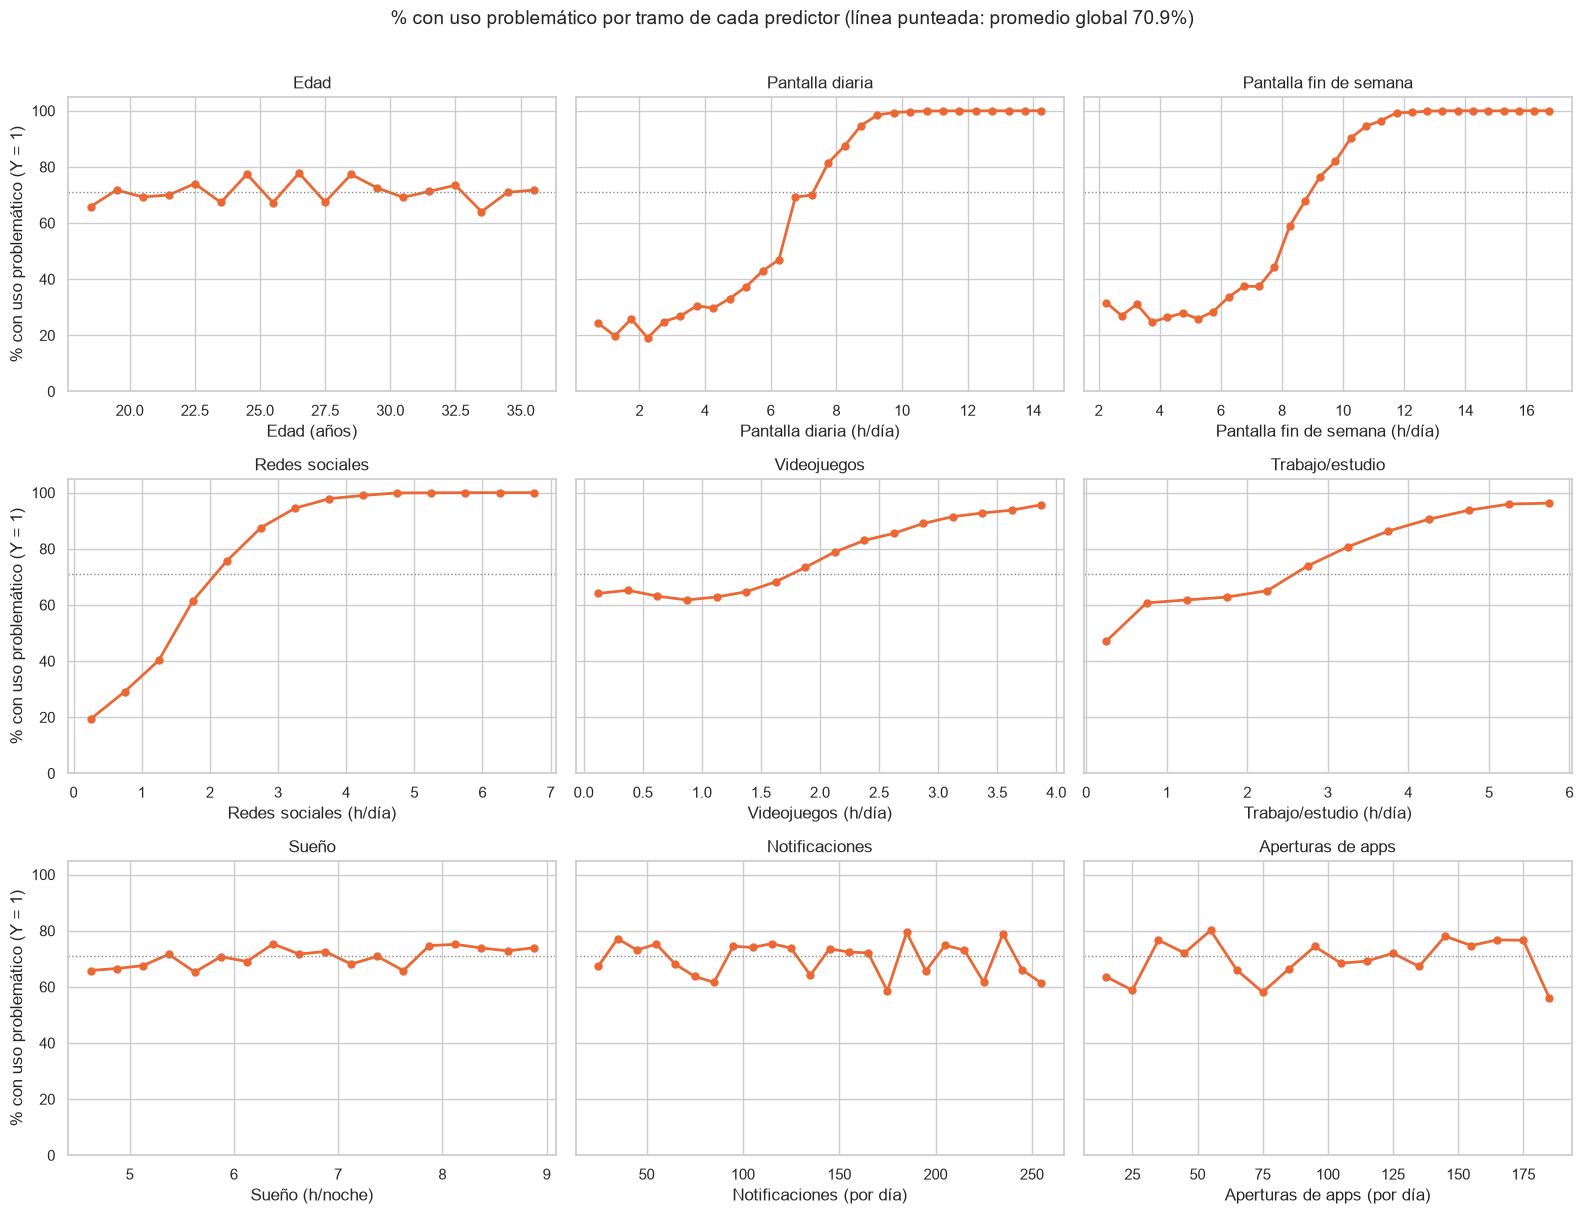

daily_screen_time_hours,0.75,1.25,1.75,2.25,2.75,3.25,3.75,4.25,4.75,5.25,...,9.75,10.25,10.75,11.25,11.75,12.25,12.75,13.25,13.75,14.25
% Y=1,24.2,19.8,25.8,19.1,24.9,26.8,30.5,29.6,33.1,37.3,...,99.4,99.7,99.9,99.9,100.0,100.0,100.0,100.0,100.0,100.0


In [24]:
ANCHO_TRAMO = {'age': 1, 'daily_screen_time_hours': 0.5, 'weekend_screen_time': 0.5, 'social_media_hours': 0.5,
               'gaming_hours': 0.25, 'work_study_hours': 0.5, 'sleep_hours': 0.25,
               'notifications_per_day': 10, 'app_opens_per_day': 10}


def tasa_por_tramo(col, ancho, datos=df, min_obs=200):
    d = datos[[col, Y]].dropna()
    inicio = np.floor(d[col] / ancho) * ancho
    t = d.groupby(inicio)[Y].agg(tasa='mean', n='size')
    t = t[t['n'] >= min_obs]
    t.index = t.index + ancho / 2  # centro del tramo
    return t


fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharey=True)
for ax, col in zip(axes.flat, num_cols):
    t = tasa_por_tramo(col, ANCHO_TRAMO[col])
    ax.plot(t.index, t['tasa'] * 100, color=COLOR_Y[1], lw=2, marker='o', ms=5)
    ax.axhline(TASA_GLOBAL * 100, color=GRIS, ls=':', lw=1)
    ax.set_ylim(0, 105)
    ax.set_title(nombre(col))
    ax.set_xlabel(etiqueta(col))
for ax in axes[:, 0]:
    ax.set_ylabel('% con uso problemático (Y = 1)')
plt.suptitle(f'% con uso problemático por tramo de cada predictor (línea punteada: promedio global {TASA_GLOBAL:.1%})',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Valores de la curva de pantalla diaria (tramos de 0,5 h; el índice es el centro del tramo)
curva = tasa_por_tramo('daily_screen_time_hours', 0.5)
display((curva['tasa'] * 100).round(1).to_frame('% Y=1').T)

**Interpretación — se distinguen tres patrones:**

1. **Efecto umbral (curva en S) en pantalla diaria, fin de semana y redes sociales.** Con menos de ≈ 4 h diarias de pantalla, la tasa de uso problemático se mantiene en una meseta de ≈ 20–30 %; entre 4,5 y 9 h sube bruscamente (cruza el 50 % cerca de las 6,5 h, con un salto de 47 % a 69 %) y desde las 9 h supera el 98 %, llegando prácticamente al 100 % sobre 10 h. En redes sociales ocurre lo mismo a menor escala: 19 % con menos de 0,5 h, 61 % entre 1,5 y 2 h y ≥ 99 % desde las 4 h. **La relación no es lineal**: un modelo lineal subestimaría el efecto en la zona de transición y lo sobreestimaría en los extremos.
2. **Relación creciente pero moderada en videojuegos y trabajo/estudio.** Videojuegos se mantiene plano (≈ 62–66 %) hasta ≈ 1,5 h y luego sube hasta ≈ 95 %; trabajo/estudio crece de forma más gradual (≈ 47 % → 96 %).
3. **Sin tendencia en edad, sueño, notificaciones y aperturas.** Las curvas oscilan alrededor del promedio global. Llama la atención que en notificaciones, aperturas y edad las oscilaciones entre tramos vecinos son grandes, algo poco esperable en un fenómeno real y relacionado con lo observado en 3.3.

La meseta inferior (≈ 25 % y no 0 %) indica que, incluso con poco tiempo de pantalla, 1 de cada 4 personas está etiquetada con uso problemático: algo distinto al tiempo total explica esos casos (ver la interacción con redes sociales en 6.6).

### 6.4 Una relación no lineal oculta: los valores exactos de notificaciones y aperturas

En 6.2 vimos que notificaciones y aperturas de apps no tienen relación monótona con $Y$ (AUC ≈ 0,5), pero sí separan $Y$ cuando se usa su valor exacto (AUC ≈ 0,75). Para entenderlo, calculamos la tasa de $Y$ para **cada valor exacto** y la comparamos con el tiempo de pantalla promedio de las personas que tienen ese valor.

Notificaciones: % Y=1 por valor entre 11.9% y 98.6% | V de Cramér = 0.428 (≈ 0.019 si no hubiera asociación) | correlación entre tasa por valor y pantalla promedio: r = 0.91
Aperturas de apps: % Y=1 por valor entre 11.4% y 98.5% | V de Cramér = 0.414 (≈ 0.016 si no hubiera asociación) | correlación entre tasa por valor y pantalla promedio: r = 0.94


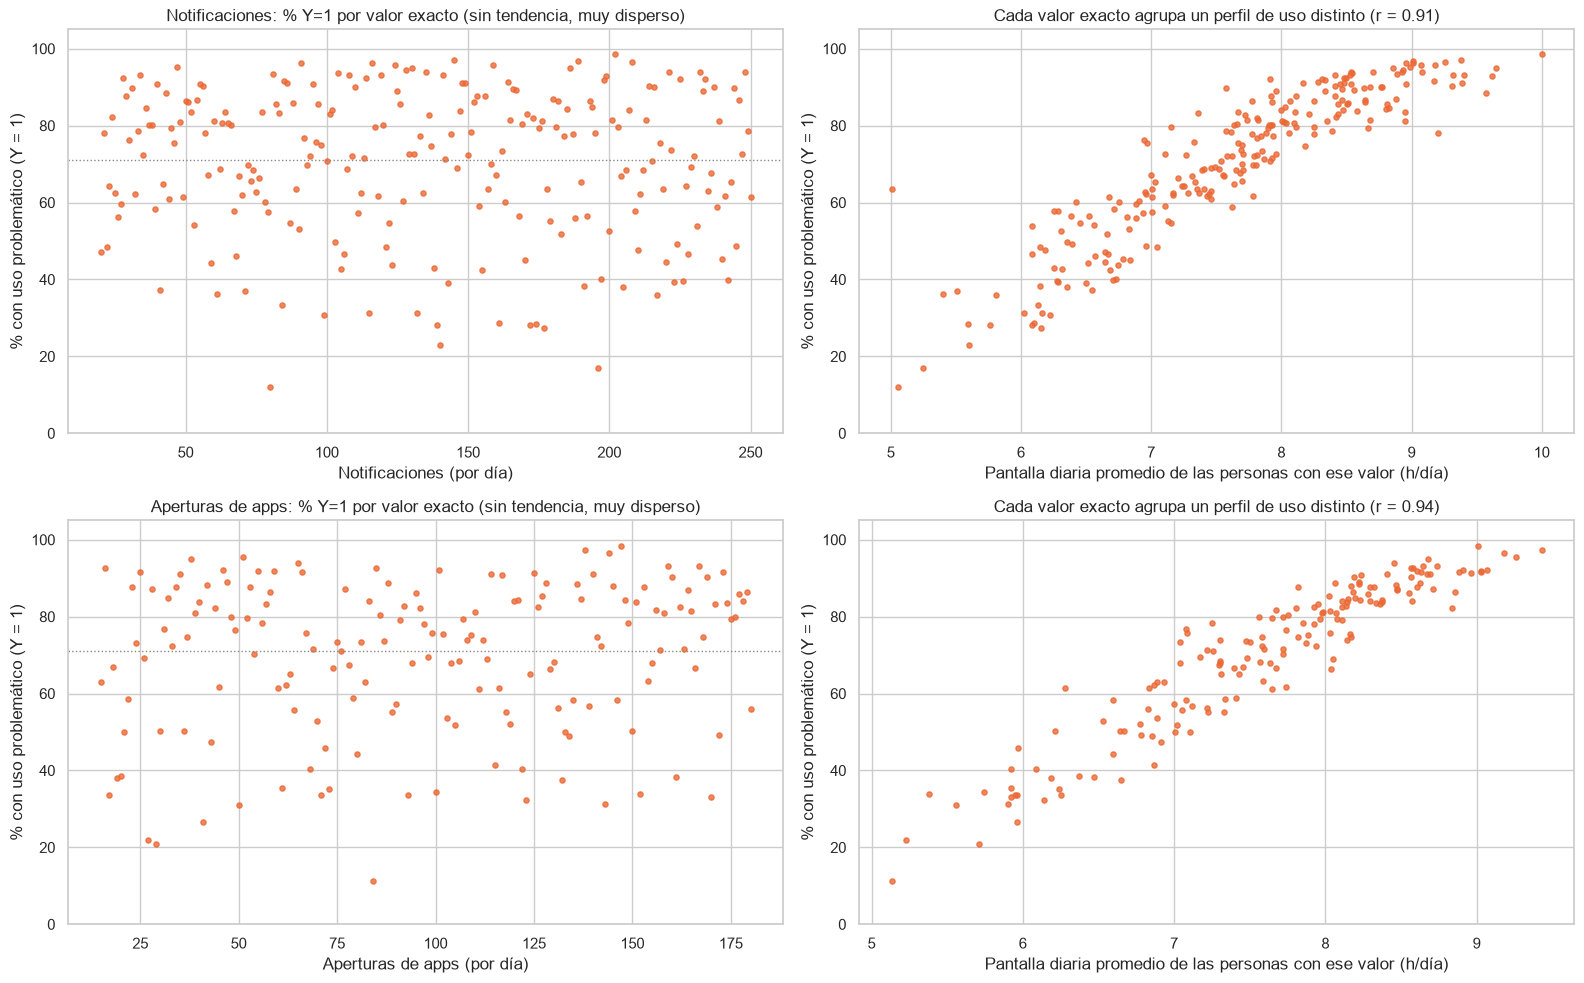


Edad: V de Cramér = 0.084 | % Y=1 en edades pares: 72.8% vs impares: 69.2%


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for fila, col in zip(axes, ['notifications_per_day', 'app_opens_per_day']):
    por_valor = df.groupby(col).agg(tasa=(Y, 'mean'), n=(Y, 'size'), pantalla=('daily_screen_time_hours', 'mean'))
    d = df[[col, Y]].dropna()
    v = cramer_v(d[col], d[Y])
    v_azar = np.sqrt((d[col].nunique() - 1) / len(d))  # valor aproximado esperado si no hubiera asociación
    r = por_valor['tasa'].corr(por_valor['pantalla'])

    ax = fila[0]
    ax.scatter(por_valor.index, por_valor['tasa'] * 100, s=14, color=COLOR_Y[1], alpha=0.8)
    ax.axhline(TASA_GLOBAL * 100, color=GRIS, ls=':', lw=1)
    ax.set_ylim(0, 105)
    ax.set_xlabel(etiqueta(col))
    ax.set_ylabel('% con uso problemático (Y = 1)')
    ax.set_title(f'{nombre(col)}: % Y=1 por valor exacto (sin tendencia, muy disperso)')

    ax = fila[1]
    ax.scatter(por_valor['pantalla'], por_valor['tasa'] * 100, s=14, color=COLOR_Y[1], alpha=0.8)
    ax.set_ylim(0, 105)
    ax.set_xlabel('Pantalla diaria promedio de las personas con ese valor (h/día)')
    ax.set_ylabel('% con uso problemático (Y = 1)')
    ax.set_title(f'Cada valor exacto agrupa un perfil de uso distinto (r = {r:.2f})')

    print(f"{nombre(col)}: % Y=1 por valor entre {por_valor['tasa'].min():.1%} y {por_valor['tasa'].max():.1%} | "
          f"V de Cramér = {v:.3f} (≈ {v_azar:.3f} si no hubiera asociación) | "
          f"correlación entre tasa por valor y pantalla promedio: r = {r:.2f}")
plt.tight_layout()
plt.show()

# Efecto similar, pero mucho más débil, en la edad
edad_obs = df['age'].notna()
pares = edad_obs & (df['age'] % 2 == 0)
print(f"\nEdad: V de Cramér = {cramer_v(df.loc[edad_obs, 'age'], df.loc[edad_obs, Y]):.3f} | "
      f"% Y=1 en edades pares: {df.loc[pares, Y].mean():.1%} vs impares: {df.loc[edad_obs & ~pares, Y].mean():.1%}")

**Interpretación:**

* La tasa de $Y$ por valor exacto va desde ≈ 11 % hasta ≈ 98 % sin ninguna tendencia: tener 80 o 200 notificaciones no implica más o menos uso problemático. Aun así, la V de Cramér (≈ 0,42) es unas 20 veces mayor que la esperable por azar (≈ 0,02).
* El panel derecho explica el fenómeno: los valores con tasa alta de $Y$ son aquellos cuyas personas tienen, en promedio, mucho tiempo de pantalla (r ≈ 0,91–0,94). Es decir, **cada valor exacto funciona como una "huella" de un perfil de uso**, no como una medida con significado propio. Por ejemplo, quienes reportan exactamente 80 notificaciones usan en promedio ≈ 5 h de pantalla y solo el 12 % tiene Y=1, mientras que quienes reportan 202 usan ≈ 10 h y el 99 % tiene Y=1.
* La edad muestra un efecto similar pero mucho más débil (V ≈ 0,08): las edades pares tienen ≈ 3,5 p.p. más de uso problemático que las impares, algo sin explicación sustantiva.
* Este comportamiento es característico de **datos sintéticos** generados a partir de un dataset original pequeño: los valores del original se replican muchas veces junto con su perfil. Es, por lo tanto, un **artefacto del proceso de generación** y no un patrón de comportamiento real.

> **Para el modelado:** estas variables **no son ruido puro** para un modelo flexible (los árboles o el *boosting* pueden aprender la "huella" de cada valor; ver el chequeo de la sección 8), pero esa señal probablemente no se generalizaría a datos reales. En el Avance 3 conviene entrenar modelos **con y sin** notificaciones y aperturas, y reportar ambos resultados.

### 6.5 Relaciones entre predictores (multicolinealidad)

Si dos predictores contienen la misma información, un modelo lineal puede volverse inestable o difícil de interpretar. Usamos la correlación de Spearman (captura relaciones monótonas y no asume normalidad).

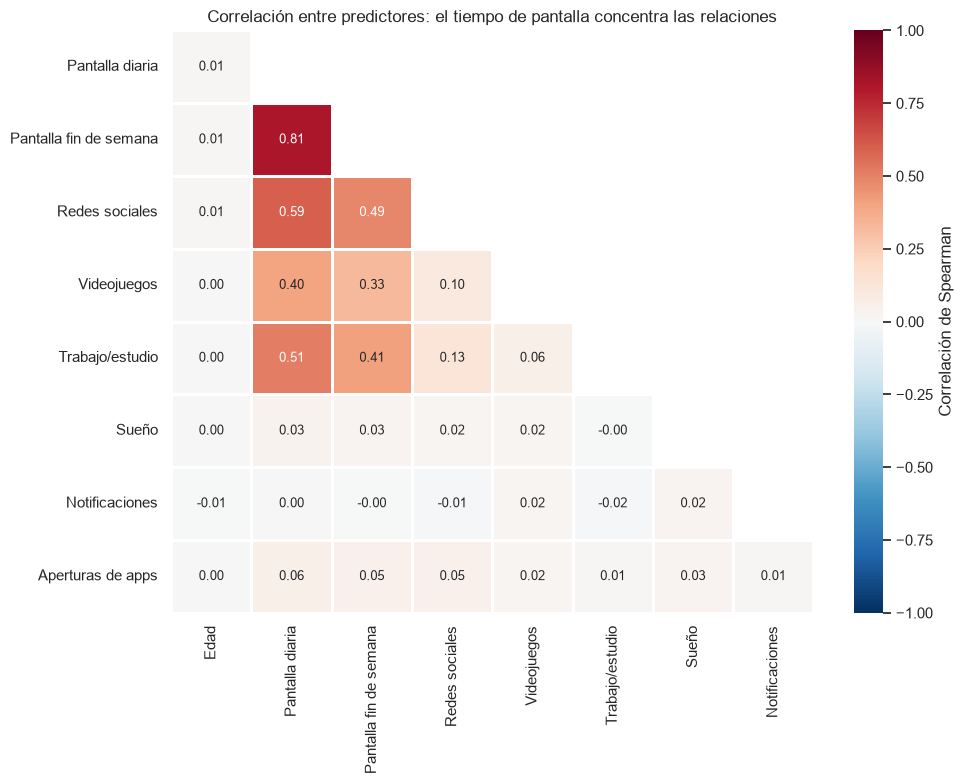

In [26]:
corr_x = df[num_cols].corr(method='spearman')
corr_x.index = corr_x.columns = [nombre(c) for c in num_cols]
corr_x = corr_x.iloc[1:, :-1]  # se omiten la fila y columna que quedarían vacías
mascara = np.triu(np.ones_like(corr_x, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_x, mask=mascara, cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size': 9}, linewidths=1, linecolor='white',
            cbar_kws={'label': 'Correlación de Spearman'}, ax=ax)
ax.grid(False)
ax.set_title('Correlación entre predictores: el tiempo de pantalla concentra las relaciones')
plt.tight_layout()
plt.show()

**Interpretación:**

* **Pantalla diaria y de fin de semana están muy correlacionadas (0,81):** son dos mediciones del mismo nivel de uso. No son idénticas (ver secciones 7 y 8), pero usarlas juntas en un modelo lineal sin regularización generaría coeficientes inestables.
* **La pantalla diaria se correlaciona con sus componentes** (redes 0,59; trabajo/estudio 0,51; videojuegos 0,40), coherente con que sea el tiempo total. En cambio, **los componentes casi no se relacionan entre sí** (≤ 0,13): quien juega mucho no necesariamente usa mucho las redes sociales. Son perfiles de uso distintos.
* **Edad, sueño, notificaciones y aperturas no se correlacionan con nada** (|r| ≤ 0,06). Resultado inesperado: según nuestra problemática esperábamos que más pantalla se asociara a **menos sueño**, pero la correlación es ≈ 0,03. Es otro indicio de que el dataset no reproduce algunas relaciones esperables en una población real.

### 6.6 Interacciones: ¿el efecto de una variable depende de otra?

Dos preguntas: (1) ¿las redes sociales aportan información **dentro** de un mismo nivel de pantalla total? y (2) ¿el nivel de estrés modifica el efecto del tiempo de pantalla?

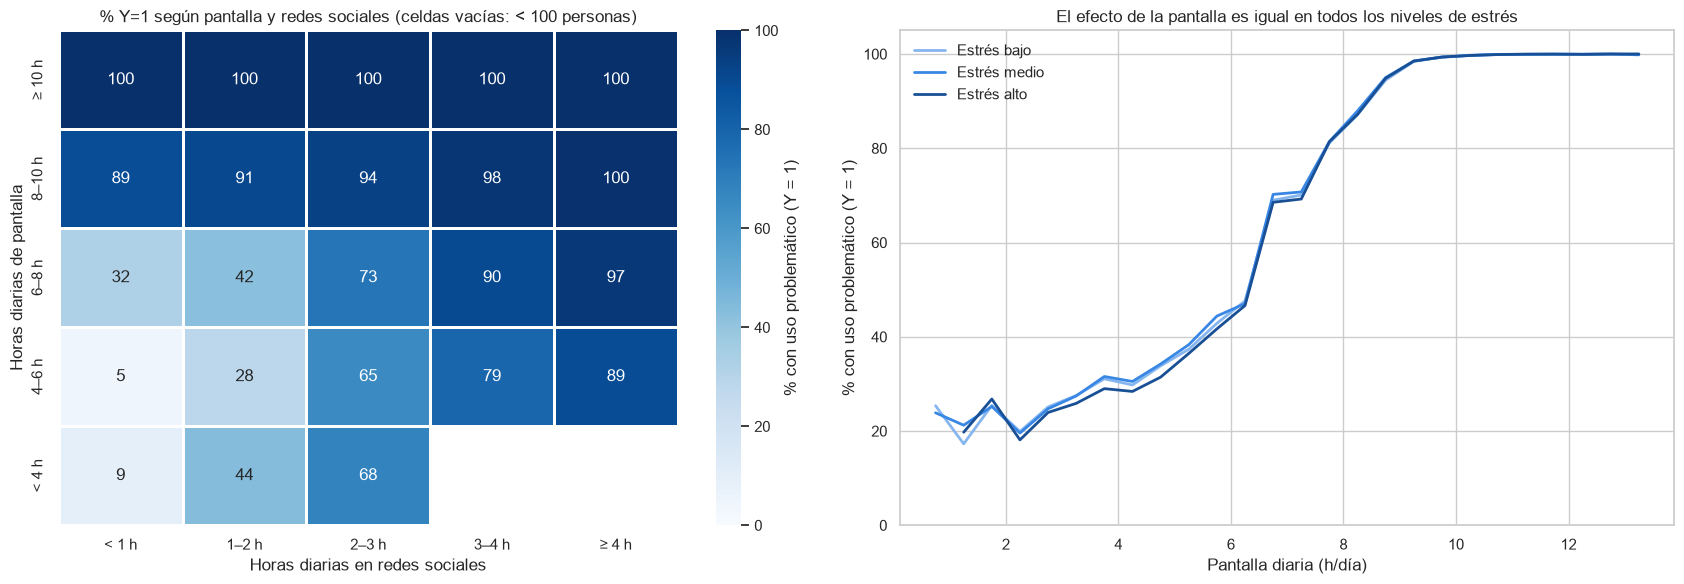

Pantalla diaria (h),1–2,2–3,3–4,4–5,5–6,6–7,7–8,8–9,9–10,10–11,11–12,12–13
n,4132.000,16307.000,30098.000,50623.000,51954.000,56929.000,51719.000,54859.000,68078.000,56809.000,45291.000,12515.000
% Y=1,23.766,22.898,29.019,31.385,40.224,57.031,75.736,91.225,98.890,99.787,99.945,99.960
AUC redes sociales,0.808,0.816,0.841,0.820,0.811,0.778,0.759,0.751,0.725,0.734,0.651,0.635


In [27]:
tramos_pantalla = ([0, 4, 6, 8, 10, 24], ['< 4 h', '4–6 h', '6–8 h', '8–10 h', '≥ 10 h'])
tramos_redes = ([0, 1, 2, 3, 4, 24], ['< 1 h', '1–2 h', '2–3 h', '3–4 h', '≥ 4 h'])
d = df[['daily_screen_time_hours', 'social_media_hours', Y]].dropna()
d['tramo_pantalla'] = pd.cut(d['daily_screen_time_hours'], tramos_pantalla[0], labels=tramos_pantalla[1], right=False)
d['tramo_redes'] = pd.cut(d['social_media_hours'], tramos_redes[0], labels=tramos_redes[1], right=False)
agrupado = d.groupby(['tramo_pantalla', 'tramo_redes'], observed=False)[Y]
mapa = (agrupado.mean() * 100).unstack().where(agrupado.size().unstack() >= 100)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.heatmap(mapa, cmap='Blues', vmin=0, vmax=100, annot=True, fmt='.0f', linewidths=2, linecolor='white',
            cbar_kws={'label': '% con uso problemático (Y = 1)'}, ax=axes[0])
axes[0].invert_yaxis()
axes[0].grid(False)
axes[0].set_xlabel('Horas diarias en redes sociales')
axes[0].set_ylabel('Horas diarias de pantalla')
axes[0].set_title('% Y=1 según pantalla y redes sociales (celdas vacías: < 100 personas)')

# Efecto de la pantalla según el nivel de estrés (rampa ordinal de un solo tono)
rampa_estres = {'Low': '#86b6ef', 'Medium': '#3987e5', 'High': '#184f95'}
for nivel, color in rampa_estres.items():
    t = tasa_por_tramo('daily_screen_time_hours', 0.5, datos=df[df['stress_level'] == nivel])
    axes[1].plot(t.index, t['tasa'] * 100, color=color, lw=2, label=f'Estrés {TRADUCCION[nivel].lower()}')
axes[1].set_ylim(0, 105)
axes[1].set_xlabel(etiqueta('daily_screen_time_hours'))
axes[1].set_ylabel('% con uso problemático (Y = 1)')
axes[1].set_title('El efecto de la pantalla es igual en todos los niveles de estrés')
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

# AUC de redes sociales dentro de cada tramo de 1 h de pantalla diaria
filas = []
d['hora'] = np.floor(d['daily_screen_time_hours'])
for hora, sub in d.groupby('hora'):
    if sub[Y].nunique() == 2 and len(sub) >= 1000:
        filas.append({'Pantalla diaria (h)': f'{hora:.0f}–{hora + 1:.0f}', 'n': len(sub), '% Y=1': sub[Y].mean() * 100,
                      'AUC redes sociales': roc_auc_score(sub[Y], sub['social_media_hours'])})
display(pd.DataFrame(filas).set_index('Pantalla diaria (h)').round(3).T)

**Interpretación:**

* **Las redes sociales aportan información adicional al tiempo total, sobre todo cuando el uso total es bajo o medio.** Con menos de 4 h de pantalla, quien usa < 1 h de redes tiene 9 % de uso problemático, mientras que quien usa 2–3 h tiene 68 %; entre 4 y 6 h de pantalla, la tasa va de 5 % (< 1 h de redes) a 89 % (≥ 4 h). Dentro de cada tramo de 1 h de pantalla (hasta las 11 h), las redes sociales siguen separando $Y$ con AUC entre 0,72 y 0,84. Es una **interacción**: el efecto de las redes depende del nivel de pantalla total (sobre 10 h casi todos son Y=1, sin importar las redes).
* **El estrés no modifica el efecto del tiempo de pantalla:** las tres curvas se superponen casi por completo. Esto refuerza que el estrés no aporta información sobre $Y$, ni por sí solo (5.1) ni en combinación.

> **Para el modelado:** el efecto umbral y la interacción pantalla × redes favorecen modelos no lineales (árboles, *random forest*, *gradient boosting*). Si se usa regresión logística, debería incluir tramos o *splines* y términos de interacción.

---
## 7. Componente temporal/contextual $T$: semana típica (día hábil vs fin de semana)

En el Avance 1 definimos $T$ como **una semana típica de uso**, representada por el par `daily_screen_time_hours` (día hábil) / `weekend_screen_time` (fin de semana). No hay fechas, por lo que no es posible estudiar tendencias ni estacionalidad. Analizamos entonces:

1. ¿Cuánto cambia el uso entre día hábil y fin de semana?
2. ¿Ese cambio es distinto en quienes tienen uso problemático?
3. ¿Cambia entre grupos de contexto (género, estrés, edad)?

In [28]:
t_df = df_proc[['daily_screen_time_hours', 'weekend_screen_time', 'dif_finde_hours', Y, 'gender', 'stress_level']]
t_df = t_df.dropna(subset=['dif_finde_hours']).assign(grupo_edad=grupo_edad)

resumen_t = t_df.groupby(Y).agg(
    n=('dif_finde_hours', 'size'),
    pantalla_diaria_media=('daily_screen_time_hours', 'mean'),
    pantalla_finde_media=('weekend_screen_time', 'mean'),
    aumento_medio=('dif_finde_hours', 'mean'),
    aumento_mediano=('dif_finde_hours', 'median'),
    pct_usa_mas_finde=('dif_finde_hours', lambda s: (s > 0).mean() * 100),
)
resumen_t.index = ['Y = 0', 'Y = 1']
display(resumen_t.round(2))

print(f"Aumento promedio en fin de semana (todos): {t_df['dif_finde_hours'].mean():.2f} h")
print(f"AUC de la diferencia fin de semana − diario para separar Y: {roc_auc_score(t_df[Y], t_df['dif_finde_hours']):.3f} (0,5 = azar)")
print(f"Correlación pantalla diaria vs fin de semana: r = {t_df['daily_screen_time_hours'].corr(t_df['weekend_screen_time']):.2f}\n")

print('Aumento promedio en fin de semana (h) por grupo de contexto:')
for col, titulo in [('gender', 'Género'), ('stress_level', 'Nivel de estrés'), ('grupo_edad', 'Grupo de edad')]:
    medias = t_df.groupby(col, observed=True)['dif_finde_hours'].mean()
    print(f"  {titulo}: " + ' | '.join(f'{k}: {v:.2f}' for k, v in medias.items()))

,n,pantalla_diaria_media,pantalla_finde_media,aumento_medio,aumento_mediano,pct_usa_mas_finde
Y = 0,150768,5.05,6.85,1.80,1.82,84.35
Y = 1,367138,8.70,10.56,1.85,1.85,85.47


Aumento promedio en fin de semana (todos): 1.84 h
AUC de la diferencia fin de semana − diario para separar Y: 0.508 (0,5 = azar)
Correlación pantalla diaria vs fin de semana: r = 0.80

Aumento promedio en fin de semana (h) por grupo de contexto:
  Género: Male: 1.85 | Female: 1.83 | Other: 1.83
  Nivel de estrés: Low: 1.83 | Medium: 1.85 | High: 1.83
  Grupo de edad: 18–22: 1.83 | 23–27: 1.84 | 28–31: 1.83 | 32–35: 1.84


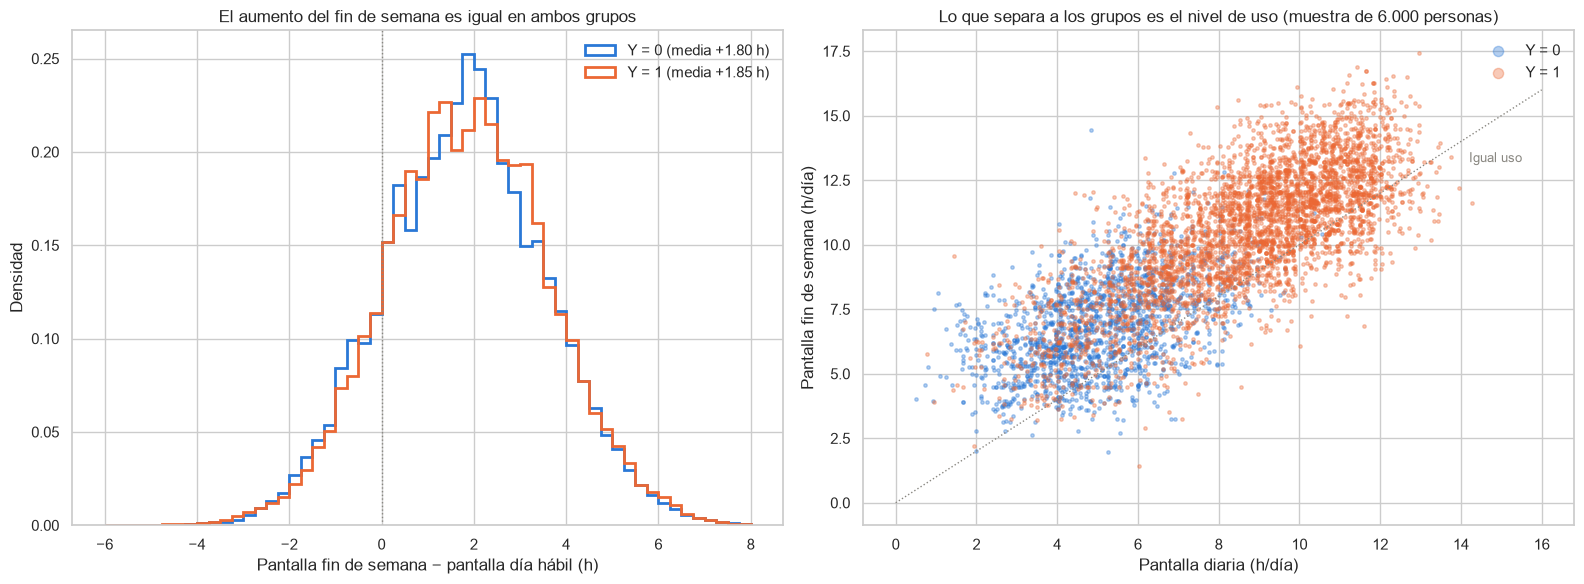

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bordes = np.arange(-6, 8.25, 0.25)
for clase in (0, 1):
    valores = t_df.loc[t_df[Y] == clase, 'dif_finde_hours']
    axes[0].hist(valores, bins=bordes, density=True, histtype='step', lw=2, color=COLOR_Y[clase],
                 label=f'Y = {clase} (media {valores.mean():+.2f} h)')
axes[0].axvline(0, color=GRIS, ls=':', lw=1)
axes[0].set_xlabel('Pantalla fin de semana − pantalla día hábil (h)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('El aumento del fin de semana es igual en ambos grupos')
axes[0].legend(frameon=False)

muestra_t = t_df.sample(6000, random_state=42)
for clase in (0, 1):
    m = muestra_t[muestra_t[Y] == clase]
    axes[1].scatter(m['daily_screen_time_hours'], m['weekend_screen_time'], s=6, alpha=0.35,
                    color=COLOR_Y[clase], label=f'Y = {clase}')
axes[1].plot([0, 16], [0, 16], color=GRIS, ls=':', lw=1)
axes[1].text(14.2, 13.2, 'Igual uso', color=GRIS, fontsize=9)
axes[1].set_xlabel(etiqueta('daily_screen_time_hours'))
axes[1].set_ylabel(etiqueta('weekend_screen_time'))
axes[1].set_title('Lo que separa a los grupos es el nivel de uso (muestra de 6.000 personas)')
axes[1].legend(frameon=False, markerscale=3)
plt.tight_layout()
plt.show()

**Interpretación:**

* **El fin de semana el uso aumenta ≈ 1,8 h** respecto de un día hábil, y el 85 % de las personas usa más pantalla el fin de semana.
* **Ese aumento es prácticamente idéntico en ambos grupos** (+1,80 h en Y=0 vs +1,85 h en Y=1) y la diferencia fin de semana − diario no separa $Y$ (AUC ≈ 0,51). En el gráfico de dispersión, ambas nubes se ubican paralelas a la diagonal: lo que distingue a quienes tienen uso problemático es que usan ≈ 3,7 h más **tanto en la semana como el fin de semana**, no un patrón distinto de fin de semana.
* **El contexto semanal tampoco cambia entre grupos:** el aumento es ≈ 1,83–1,85 h en todos los géneros, niveles de estrés y grupos de edad.
* **Relación con la pregunta:** la idea de que el uso problemático se manifieste como un "atracón" de fin de semana no se observa en estos datos. La información útil de $T$ está en el **nivel** de uso en ambos momentos de la semana.

> **Para el modelado:** no vale la pena usar la diferencia fin de semana − diario como predictor. Pantalla diaria y de fin de semana están muy correlacionadas (r = 0,80), pero no son completamente redundantes: el chequeo de la sección 8 muestra que combinarlas mejora la separación, y una puede ayudar a imputar la otra cuando falta.

---
## 8. Chequeo preliminar: ¿cuánta información aporta cada grupo de variables?

*Esto **no** es el modelo del Avance 3*: no hay ajuste de hiperparámetros ni conjunto de prueba final. Es solo una verificación rápida para **cuantificar** las conclusiones del EDA. Usamos `HistGradientBoostingClassifier` (acepta faltantes y categorías sin preprocesar, y captura no linealidades) con validación cruzada de 3 folds sobre una muestra de 200.000 personas, y comparamos el ROC-AUC obtenido con distintos grupos de variables.

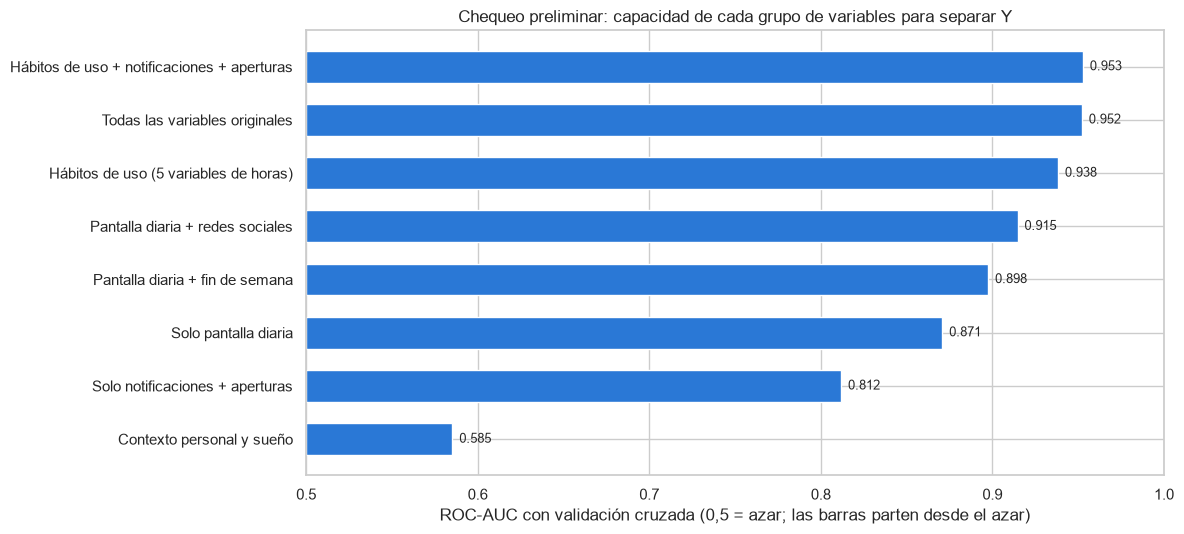

In [30]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score

muestra = df_proc.sample(200_000, random_state=0)
uso = ['daily_screen_time_hours', 'weekend_screen_time', 'social_media_hours', 'gaming_hours', 'work_study_hours']
grupos_vars = {
    'Contexto personal y sueño': ['age', 'gender', 'stress_level', 'academic_work_impact', 'sleep_hours'],
    'Solo notificaciones + aperturas': ['notifications_per_day', 'app_opens_per_day'],
    'Solo pantalla diaria': ['daily_screen_time_hours'],
    'Pantalla diaria + fin de semana': ['daily_screen_time_hours', 'weekend_screen_time'],
    'Pantalla diaria + redes sociales': ['daily_screen_time_hours', 'social_media_hours'],
    'Hábitos de uso (5 variables de horas)': uso,
    'Hábitos de uso + notificaciones + aperturas': uso + ['notifications_per_day', 'app_opens_per_day'],
    'Todas las variables originales': predictores,
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
resultados = {}
for nombre_grupo, columnas in grupos_vars.items():
    modelo = HistGradientBoostingClassifier(categorical_features='from_dtype', random_state=0)
    resultados[nombre_grupo] = cross_val_score(modelo, muestra[columnas], muestra[Y], cv=cv, scoring='roc_auc').mean()
resultados = pd.Series(resultados).sort_values()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.barh(resultados.index, resultados.values - 0.5, left=0.5, color=COLOR_Y[0], height=0.6)
for i, v in enumerate(resultados.values):
    ax.text(v + 0.004, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('ROC-AUC con validación cruzada (0,5 = azar; las barras parten desde el azar)')
ax.set_title('Chequeo preliminar: capacidad de cada grupo de variables para separar Y')
plt.tight_layout()
plt.show()

**Interpretación:**

* El **contexto personal y el sueño** (edad, género, estrés, impacto académico/laboral y sueño) apenas superan el azar (AUC 0,585), lo que confirma lo observado en 5.1 y 6.2. Además, usar todas las variables (0,952) no mejora respecto de usar solo hábitos de uso + notificaciones + aperturas (0,953): el contexto personal no agrega nada.
* **Solo la pantalla diaria** ya alcanza un AUC de 0,871; agregar **redes sociales** lo sube a 0,915 (la interacción de 6.6) y el conjunto de **hábitos de uso** llega a 0,938.
* Agregar **fin de semana** a la pantalla diaria también mejora (0,871 → 0,898), en parte porque cuando falta una medida la otra la reemplaza: no son redundantes.
* **Notificaciones + aperturas por sí solas logran un AUC de 0,812**, a pesar de tener correlación ≈ 0 con $Y$, y agregadas a los hábitos de uso suben el AUC de 0,938 a 0,953. Esto confirma que la "huella" de sus valores exactos (6.4) es aprovechable por un modelo flexible, por lo que habrá que decidir conscientemente si se usa.
* Que con tan pocas variables se alcance un AUC tan alto refuerza la sospecha de que la etiqueta podría haberse construido a partir de estas mismas variables (ver limitaciones).

---
## 9. Síntesis del EDA: hallazgos principales

Cada hallazgo sigue la secuencia **Evidencia → Patrón → Interpretación → relación con la pregunta**.

| # | Hallazgo | Evidencia (sección) | Interpretación y relación con la pregunta |
|---|---|---|---|
| **H1** | **$Y$ está desbalanceada y no depende del perfil demográfico** | 70,9 % con uso problemático (2,4 : 1). Diferencias entre grupos ≤ 2,5 p.p. y V de Cramér ≤ 0,03 (sección 5) | La clase "problemática" es la mayoritaria, por lo que el *accuracy* será engañoso. El uso problemático no se concentra en un género, edad o nivel de estrés. |
| **H2** | **El tiempo de pantalla y las redes sociales concentran la información sobre $Y$** | AUC 0,89 (diaria), 0,88 (fin de semana), 0,86 (redes); mediana de pantalla 9,1 h (Y=1) vs 5,0 h (Y=0) (6.1–6.2) | Responde a la pregunta: **sí** es posible identificar el uso problemático a partir de los hábitos digitales, principalmente *cuánto* se usa la pantalla y *en qué*. |
| **H3** | **La relación es no lineal (efecto umbral) y con interacción pantalla × redes** | Meseta de ≈ 25 % bajo 4 h; cruza el 50 % cerca de las 6,5 h; ≥ 98 % desde 9 h. Con < 4 h de pantalla: 9 % de Y=1 si usa < 1 h de redes vs 68 % si usa 2–3 h; AUC de redes dentro de cada nivel de pantalla 0,72–0,84 (6.3, 6.6) | Un modelo lineal simple sería inadecuado. Bajo el umbral, las redes sociales marcan la diferencia. |
| **H4** | **El contexto personal y el sueño no aportan; notificaciones y aperturas solo aportan por un artefacto** | Estrés V = 0,006, impacto V = 0,003, sueño AUC 0,53, contexto + sueño juntos AUC 0,585, correlación sueño–pantalla 0,03. Notificaciones/aperturas: AUC monótono ≈ 0,5 pero V ≈ 0,42 por valor exacto, ligado al perfil de uso (r ≈ 0,9) (6.2, 6.4) | Resultado inesperado respecto de la pregunta inicial, que incluía sueño y contexto personal. La señal de notificaciones/aperturas parece producto de la generación sintética del dataset y no un comportamiento real. |
| **H5** | **El contexto semanal $T$ no distingue grupos** | El fin de semana se usa +1,80 h (Y=0) vs +1,85 h (Y=1); AUC de la diferencia = 0,51; aumento igual en todos los grupos de contexto (sección 7) | El uso problemático se refleja en el **nivel** de uso en ambos momentos de la semana, no en un patrón distinto de fin de semana. |

### 9.1 Limitaciones detectadas

* **Indicios de datos sintéticos:** distribuciones uniformes en edad, sueño, notificaciones y aperturas; valores exactos repetidos de forma irregular; ausencia de relaciones esperables (sueño–pantalla). Las conclusiones podrían no generalizarse a una población real.
* **Posible circularidad de la etiqueta:** desde las 10 h diarias de pantalla, el 99,9 % está etiquetado con uso problemático (solo 167 de 139.087 personas tienen Y=0). Es posible que `addicted_label` se haya construido a partir del tiempo de pantalla y las redes sociales; en ese caso, un modelo solo "redescubriría" esa regla.
* **Muchos faltantes repartidos:** solo el 38,9 % de las filas está completa; a favor, los faltantes no se relacionan con $Y$.
* **Diseño transversal:** $T$ es una semana típica; no se puede estudiar la evolución en el tiempo ni inferir causalidad.

### 9.2 ¿Qué implica esto para el modelado (Avance 3)?

| Evidencia del EDA | Decisión para el Avance 3 |
|---|---|
| $Y$ desbalanceada (70,9 % / 29,1 %) | Partición estratificada; métricas F1, ROC-AUC, PR-AUC y *recall* de Y=0; probar `class_weight` o ajuste de umbral |
| Faltantes repartidos, no informativos y en bloques | Imputación dentro del *pipeline*; comparar mediana/moda vs KNN/iterativa |
| Efecto umbral e interacción pantalla × redes | Modelos no lineales (árbol, *random forest*, *gradient boosting*); si se usa logística, incluir tramos/*splines* e interacciones |
| Pantalla diaria y fin de semana muy correlacionadas (r = 0,80) | Regularización en modelos lineales; usar una para imputar la otra |
| Contexto personal y sueño sin señal | Evaluar su eliminación (importancia por permutación) para simplificar el modelo |
| Señal artificial en notificaciones/aperturas | Entrenar y reportar modelos **con y sin** estas variables |
| Posible circularidad de la etiqueta | Comparar cada modelo contra una **regla simple** basada en horas de pantalla y redes sociales |
| Escalas muy distintas | Estandarizar para modelos sensibles a la escala (logística, KNN) |

### 9.3 Respuesta preliminar a la pregunta del proyecto

> *Hasta ahora, los datos muestran que el uso problemático de pantallas puede distinguirse con claridad a partir de los hábitos digitales —principalmente el tiempo total de pantalla y el tiempo en redes sociales—, con una relación de tipo umbral. En cambio, el sueño y el contexto personal (estrés, impacto académico/laboral, género y edad) aportan muy poco. La pregunta sigue teniendo sentido, pero en el Avance 3 habrá que verificar que un modelo supere de forma relevante a una regla simple basada en horas de pantalla y decidir cómo tratar las señales que parecen artefactos del dataset.*